# Note:
- Data Wrangling / Pre-Processing:
    - Import all datasets from 3a notebook for data wrangling
        - remove duplicate features
        - vertify missingness
        <!-- - engineer new features
            - Age Addition for the candidate and donor, including mean value from features that have data at registration and prior to transplant.
            - Consolidate nominal categories
- Export pickle files for further processing -->

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserImputeFunctions as ui

# set seaborn theme
sns.set_theme()

# initializing variables
REMOVE = '** REMOVE ** Engineer'
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# initialize DataFrame
df_new = pd.DataFrame(columns=['column'])

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 2.3.2
Pandas Version: 2.3.1
Seaborn Version: 0.13.2
Matplotlib Version: 3.10.5
Python Version: 3.11.13


## Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/3aClean_Heart.pkl")
df_label = pd.read_pickle("../Data/3aClean_Label.pkl")
df_can = pd.read_pickle("../Data/3aClean_CAN.pkl")
df_don = pd.read_pickle("../Data/3aClean_DON.pkl")
df_both = pd.read_pickle("../Data/3aClean_Both.pkl")
df_nominal = pd.read_pickle("../Data/3aClean_Nominal.pkl")
df_ordinal = pd.read_pickle("../Data/3aClean_Ordinal.pkl")
df_numeric = pd.read_pickle("../Data/3aClean_Numeric.pkl")
df_object = pd.read_pickle("../Data/3aClean_Object.pkl")
df_date = pd.read_pickle("../Data/3aClean_Date.pkl")
df_dict = pd.read_pickle("../Data/3aClean_Dictionary.pkl")
df_drop = pd.read_pickle("../Data/3aClean_Drop.pkl")
df_unknown = pd.read_pickle("../Data/3aClean_Unknown.pkl")

# checking for duplicated column name
df.columns[df.columns.duplicated()]

Index([], dtype='object')

## Feature Information

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Label Features: {df_label.shape[0]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Date Features: {df_date.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Object Features: {df_object.shape[0]:,}")
print(f"Numeric Features: {df_numeric.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Drop Features: {df_drop.shape[0]:,}")
print(f"Unknown Features: {df_unknown.shape[0]:,}")
print(f"Dictionary Features: {df_dict.shape[0]:,}")

Heart Dataset Rows: 28,751 & Columns: 262
Label Features: 15
Candidate Features: 139
Donor Features: 95
Date Features: 14
Both Features: 8
Object Features: 11
Numeric Features: 45
Ordinal Features: 13
Nominal Features: 179
Drop Features: 0
Unknown Features: 0
Dictionary Features: 302


In [4]:
# all label features
labelCols = df_label.column.to_list()

# display
df[labelCols].head()

,AcuteRejectionEpisode,AirwayDehiscencePostTransplant,StrokePostTransplant,PacemakerPostTransplant,DialysisPostDischarge,GraftFailStatus,GraftLifeSpanDay,LastFollowupNumber,GraftStatus,TransplantStatus,TransplantSurvivalDay,RecipientStatus,RejectionTreatmentWithinOneYear,FunctionalStatusFollowUp,LengthOfStay
0,No,No,No,No,Yes,Failure,329.0,999,No,Dead,329.0,Dead,No,"100% - Normal, no complaints, no evidence of disease",76.0
1,No,No,No,No,No,Success,2592.0,80,Yes,Alive,2592.0,Living,Missing,Unknown,10.0
2,No,No,No,No,No,Success,2913.0,80,Yes,Alive,2913.0,Living,No,Unknown,21.0
3,"Yes, at least one episode treated with anti-rejection agent",No,No,No,No,Failure,1225.0,999,No,Dead,1225.0,Dead,Yes,"30% - Severely disabled: hospitalization is indicated, death not imminent",32.0
4,No,No,No,No,No,Success,2785.0,80,Yes,Alive,2785.0,Living,No,Unknown,26.0


## Remove Unwanted Features

In [5]:
# all ordinal columns
removeCols = df_object.column.to_list()

# display
df[removeCols].head()

,VentricularDeviceTypeRegistration_CAN,VentricularDeviceTypeTransplant_CAN,VentricularDeviceBrandRegistration_CAN,VentricularDeviceBrandTransplant_CAN,PrimaryPaymentRegistration_CAN,PrimaryPaymentTransplant_CAN,DialysisTypeRegistration_CAN,CancerSite_DON,OtherMedsText1_DON,OtherMedsText2_DON,OtherMedsText3_DON
0,Lvad+Rvad,Lvad+Rvad,CentriMag (Thoratec/Levitronix),CentriMag (Thoratec/Levitronix),Public insurance - Medicaid,Public insurance - Medicaid,No dialysis,NO,"ZOSYN, VANCOMYCIN","KCL,","DOPAMINE, VASOPRESSIN,"
1,Lvad,Lvad,Heartmate II,Heartmate II,Public insurance - Medicare FFS (Fee for Service),Public insurance - Medicare FFS (Fee for Service),No dialysis,NO,"ANCEF, FENTANYL, VERSED,LASIX",NaN,NaN
2,None,None,Missing,Missing,Private insurance,Private insurance,No dialysis,NO,"ZOSYN, VANCOMYCIN","AMPHOTERICIN, BETADINE",ZANTAC
3,Lvad+Rvad,Lvad,CentriMag (Thoratec/Levitronix),Heartmate II,Public insurance - Medicare & Choice,Private insurance,No dialysis,"SKIN - SQUAMOUS, BASAL CELL","KCL, VANCO, MAG, ZOSYN","D50, DOPAMINE, DIFLUCAN",NaN
4,Lvad,Lvad,Heartmate II,Heartmate II,Public insurance - Medicare & Choice,Public insurance - Medicare & Choice,No dialysis,NO,"ROCURONIUM, VECURONIUM","ZOSYN, CIPROFLOXACIN","BUMETIDE, ANCEF"


### Examine Features - Remove Unwanted Features

In [6]:
df.VentricularDeviceTypeRegistration_CAN.value_counts(dropna=False)

VentricularDeviceTypeRegistration_CAN
None         20516
Lvad          7599
Lvad+Rvad      382
Tah            151
Missing         72
Rvad            31
Name: count, dtype: int64

In [7]:
df.VentricularDeviceTypeTransplant_CAN.value_counts(dropna=False)

VentricularDeviceTypeTransplant_CAN
None         16269
Lvad         11146
Lvad+Rvad      546
Missing        400
Tah            317
Rvad            73
Name: count, dtype: int64

In [8]:
df.DialysisTypeRegistration_CAN.value_counts(dropna=False)

### Examine Features - Remove Unwanted Features

DialysisTypeRegistration_CAN
No dialysis                              27851
Hemodialysis                               713
Missing                                     75
Peritoneal Dialysis                         64
Dialysis - Unknown Type was performed       37
Dialysis Status Unknown                     11
Name: count, dtype: int64

In [9]:
df.CancerSite_DON.value_counts(dropna=False)

CancerSite_DON
NO                                              28182
UNKNOWN                                           182
SKIN - SQUAMOUS, BASAL CELL                        87
OTHER, SPECIFY                                     73
GENITOURINARY - UTERINE CERVIX                     44
CNS TUMOR - MENINGIOMA                             19
CNS TUMOR - OTHER                                  19
GENITOURINARY - PENIS, TESTICULAR                  18
CNS TUMOR - ASTROCYTOMA                            17
THYROID                                            16
CNS TUMOR - GLIOBLASTOMA MULTIFORME                14
Missing                                            13
GENITOURINARY - OVARIAN                            12
BREAST                                             11
LEUKEMIA/LYMPHOMA                                   8
SKIN - MELANOMA                                     8
GENITOURINARY - KIDNEY                              6
GENITOURINARY - PROSTATE                            6
GASTROINTESTI

In [10]:
# remove wanted features
for col in ['VentricularDeviceTypeRegistration_CAN',
            'VentricularDeviceTypeTransplant_CAN',
            'DialysisTypeRegistration_CAN',
            'CancerSite_DON']:
    if col in removeCols:
        removeCols.remove(col)

In [11]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.house_keeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 4 row(s) from df_can DataFrame.
Remove 3 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 7 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['OtherMedsText1_DON', 'OtherMedsText2_DON', 'OtherMedsText3_DON', 'PrimaryPaymentRegistration_CAN', 'PrimaryPaymentTransplant_CAN', 'VentricularDeviceBrandRegistration_CAN', 'VentricularDeviceBrandTransplant_CAN']

Total Row(s) & Column(s) Before Removing Column(s): 28,751 & columns: 262
Total Row(s) & Column(s) After Removing Column(s): 28,751 & columns: 255


### ListingYear & Transpalnt Year

In [12]:
uf.category_contingency(df, 'ListingYear', 'RecipientStatus')

RecipientStatus,Dead,Living,Lost to Follow Up,Missing,Retransplanted,Row Total,Dead %,Living %
ListingYear,,,,,,,,
1997,1.0,0.0,0.0,0.0,0.0,1.0,100.000000,0.000000
1998,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,100.000000
1999,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,100.000000
2000,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,100.000000
2001,0.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.000000
2002,0.0,2.0,0.0,0.0,0.0,2.0,0.000000,100.000000
2003,1.0,2.0,0.0,0.0,0.0,3.0,33.333333,66.666667
2004,4.0,6.0,0.0,0.0,0.0,10.0,40.000000,60.000000
2005,2.0,6.0,0.0,0.0,0.0,8.0,25.000000,75.000000


In [13]:
uf.category_contingency(df, 'TransplantYear', 'RecipientStatus')

RecipientStatus,Dead,Living,Lost to Follow Up,Missing,Retransplanted,Row Total,Dead %,Living %
TransplantYear,,,,,,,,
2011,684.0,1169.0,51.0,0.0,45.0,1949.0,35.094920,59.979477
2012,651.0,1291.0,36.0,0.0,30.0,2008.0,32.420319,64.292829
2013,628.0,1428.0,41.0,0.0,30.0,2127.0,29.525153,67.136812
2014,619.0,1583.0,27.0,0.0,22.0,2251.0,27.498889,70.324300
2015,511.0,1777.0,30.0,0.0,29.0,2347.0,21.772476,75.713677
2016,552.0,2155.0,16.0,0.0,24.0,2747.0,20.094649,78.449217
2017,502.0,2290.0,9.0,0.0,12.0,2813.0,17.845716,81.407750
2018,413.0,2498.0,6.0,0.0,23.0,2940.0,14.047619,84.965986
2019,388.0,2641.0,1.0,0.0,15.0,3045.0,12.742200,86.732348


#### Plot

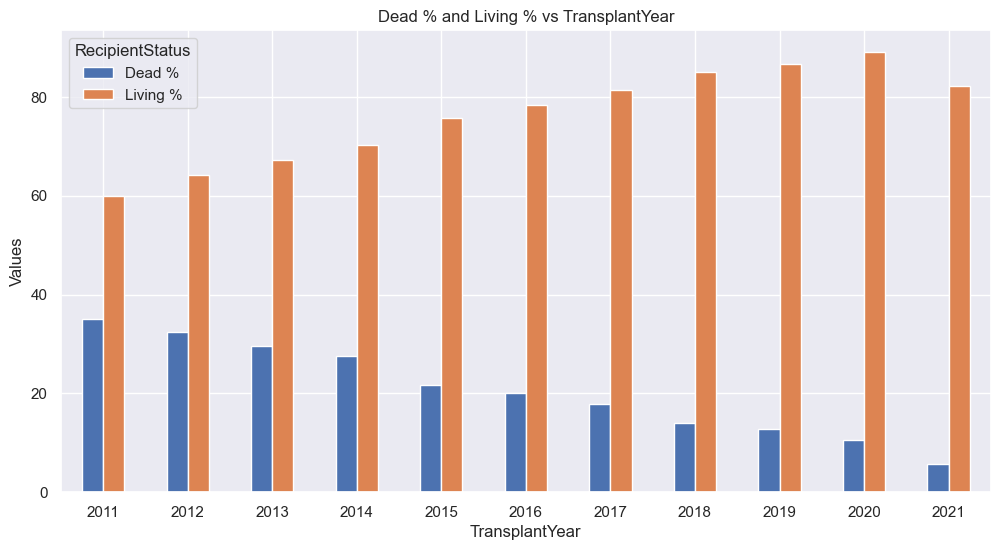

In [14]:
# get table into DataFrame
data = uf.category_contingency(df, 'TransplantYear', 'RecipientStatus')
# exclude the last row
data = data.iloc[:-1]

# 'Dead %' or 'Living %'
data = data[['Dead %', 'Living %']]

# Plotting the bar plot
data.plot(kind='bar', figsize=(12,6))
plt.title('Dead % and Living % vs TransplantYear')
plt.xlabel('TransplantYear')
plt.ylabel('Values')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

### Remove Date Columns

In [15]:
# initialize list
removeCols = df_date.column.to_list()

# remove date features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.house_keeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 7 row(s) from df_can DataFrame.
Remove 3 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 14 row(s) from df_date DataFrame.

Removed Features: ['AdmissionDate_CAN', 'AdmissionDate_DON', 'AllocationBeginDate_CAN', 'CenterDischargeDate_CAN', 'InitialWaitListDate_CAN', 'ListingYear', 'OrganRecoveryDate_DON', 'ReferralDate_DON', 'RemovalWaitListDate_CAN', 'StatusDate_CAN', 'TransplantDate_CAN', 'ValidationDateTCR_CAN', 'ValidationDateTCR_DDR', 'ValidationDateTRR_CAN']

Total Row(s) & Column(s) Before Removing Column(s): 28,751 & columns: 255
Total Row(s) & Column(s) After Removing Column(s): 28,751 & columns: 241


### Wrangle Data

#### Remove Date & NaNs > 40%

In [16]:
uf.percentage_null(df)

,percentage,NaNCount
PriorCardiacSurgeryTypeText_CAN,79.134639,22752
Class2PRA_TransplantPercentage_CAN,72.220097,20764
Class1PRA_TransplantPercentage_CAN,71.680985,20609
TotalSerumAlbuminRegistration_CAN,70.738409,20338
CPRA_Peak_CAN,46.050572,13240
CPRA_Recent_CAN,46.008834,13228
HemodynamicsRegistration_PCW_CAN,9.488366,2728
HemodynamicsTransplant_PCW_CAN,8.434489,2425
HemodynamicsRegistration_CO_CAN,5.770234,1659
HemodynamicsTransplant_CO_CAN,5.596327,1609


In [17]:
df.PriorCardiacSurgeryTypeText_CAN.value_counts(dropna=False)

PriorCardiacSurgeryTypeText_CAN
NaN                                                   22752
LVAD                                                   1894
LVAD IMPLANT                                            369
LVAD PLACEMENT                                          298
LVAD IMPLANTATION                                       203
ICD                                                     117
VAD                                                     105
AICD PLACEMENT                                           97
AICD                                                     72
VAD PLACEMENT                                            55
VAD IMPLANT                                              52
HEART TRANSPLANT                                         44
HM II LVAD                                               40
HVAD                                                     30
TAH                                                      29
BIVAD                                                    29
HEARTMAT

In [18]:
df.loc[:, df.columns.str.contains("PriorCardiacSurgery", case=False, regex=True)].head()

,PriorCardiacSurgery_CAN,PriorCardiacSurgeryType_CAN,PriorCardiacSurgeryTypeText_CAN,PriorCardiacSurgeryTypeListAndTransplant_CAN,PriorCardiacSurgeryListAndTransplant_CAN
0,Yes,Valve Replace/Repair,NaN,"Other, specify",Yes
1,No,Missing,NaN,Missing,No
2,Yes,"CABG; Other, specify",VSD,"CABG; Other, specify",Yes
3,Yes,"Other, specify",VAD PLACEMENT,"Other, specify",Yes
4,Yes,"Other, specify",LVAD IMPLANT,Missing,No


In [19]:
pd.DataFrame(df.Class2PRA_TransplantPercentage_CAN.describe()).T

,count,mean,std,min,25%,50%,75%,max
Class2PRA_TransplantPercentage_CAN,7987.0,5.980218,17.542667,0.0,0.0,0.0,0.0,100.0


In [20]:
# get NaNs
NaNsDF = uf.percentage_null(df)

# remove NaNs
removeCols = NaNsDF.index[NaNsDF.percentage > 40].to_list()

# append text fields
removeCols.extend(df_date.column.to_list())

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.house_keeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 6 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 1 row(s) from df_nominal DataFrame.
Remove 5 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['CPRA_Peak_CAN', 'CPRA_Recent_CAN', 'Class1PRA_TransplantPercentage_CAN', 'Class2PRA_TransplantPercentage_CAN', 'PriorCardiacSurgeryTypeText_CAN', 'TotalSerumAlbuminRegistration_CAN']

Total Row(s) & Column(s) Before Removing Column(s): 28,751 & columns: 241
Total Row(s) & Column(s) After Removing Column(s): 28,751 & columns: 235


#### Numerical Features

In [21]:
print(sorted(df_numeric.column.to_list()))

['Age_CAN', 'Age_DON', 'Age_Listing_CAN', 'BMI_CAN', 'BMI_DON', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_DON', 'DistanceFromDonorHospitaltoTXCenter', 'GraftLifeSpanDay', 'HeightCm_CAN', 'HeightCm_DON', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_CO_CAN', 'HemodynamicsTransplant_PA_DIA_CAN', 'HemodynamicsTransplant_PA_MN_CAN', 'HemodynamicsTransplant_PCW_CAN', 'HemodynamicsTransplant_SYS_CAN', 'IschemicTimeHour_DON', 'LV_EjectionFractionPercent_DON', 'LastFollowupNumber', 'LengthOfStay', 'Level_SGOT_ALT_DON', 'Level_SGOT_AST_DON', 'LungPO2_DON', 'LungPO2_FIO2_DON', 'OrganRecovery_PCO2_DON', 'TerminalTotalBilirubin_DON', 'TotalBilirubinTransplant_CAN', 'TotalDayWaitList_CAN', 'TransplantSurvivalDay', 'WeightKg_CAN', 'WeightKg_DON']


##### [Age](https://www.sciencedirect.com/science/article/abs/pii/S105324989800059X)
- Remove:
    - Age_Listing_CAN 

In [22]:
# examine features
features = uf.get_feature_list(df, 'Age_')

                   count       mean        std   min   25%   50%   75%   max
Age_CAN          28751.0  53.411429  12.860902  18.0  46.0  56.0  63.0  79.0
Age_DON          28751.0  32.122883  10.963701   8.0  23.0  31.0  40.0  72.0
Age_Listing_CAN  28751.0  52.802998  12.906853  12.0  46.0  56.0  63.0  78.0

:::: NaN Count:
Age_CAN            0
Age_DON            0
Age_Listing_CAN    0


In [23]:
# create new feature
df['Age_Addition'] = df.Age_CAN + df.Age_DON + df.Age_Listing_CAN
df['Age_Mean_CAN'] = (df.Age_CAN + df.Age_Listing_CAN) / 2

# initialize list
new = ['Age_Addition', 'Age_Mean_CAN']

# update dataframe
df_numeric = uf.insert_into_dataframe(df_numeric, new)
df_new = uf.insert_into_dataframe(df_new, new)
df_both = uf.insert_into_dataframe(df_both, new)
df_drop = uf.insert_into_dataframe(df_drop, features)

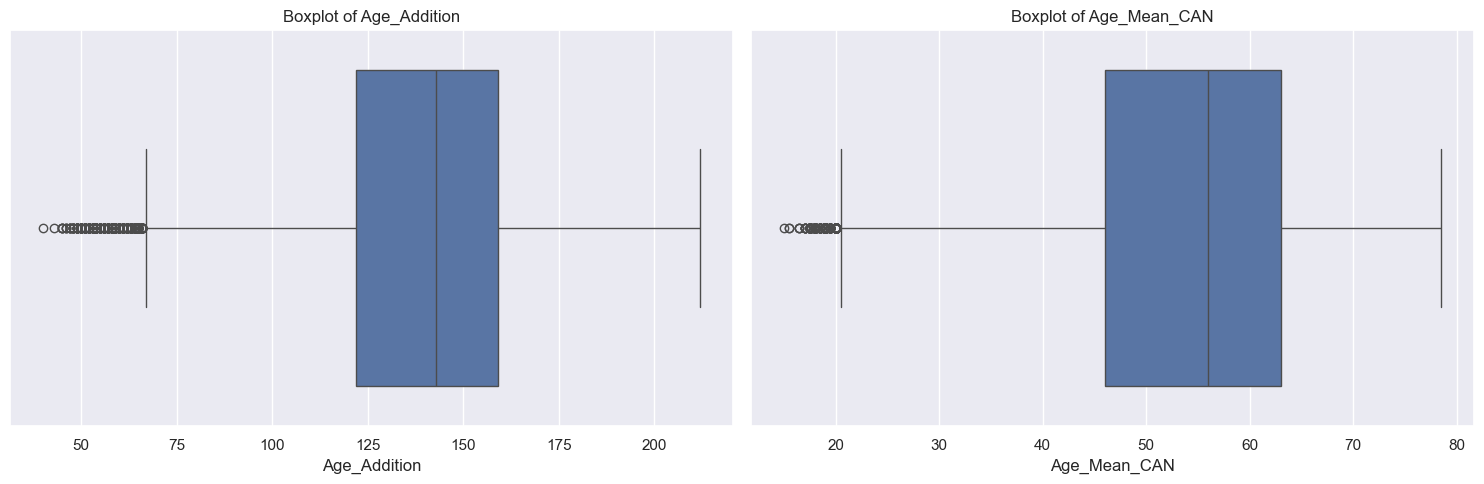

In [24]:
# boxplot
uv.plot_box(df, new, orientation='h')

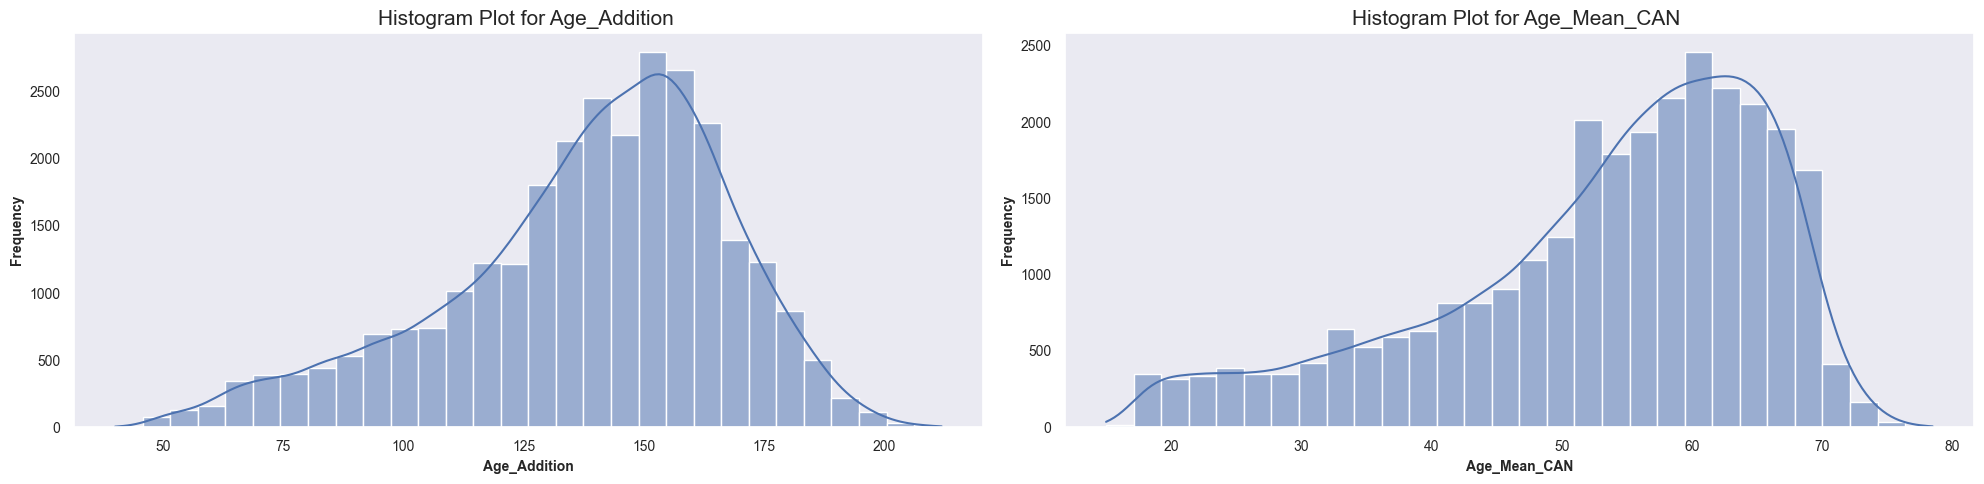

In [25]:
uv.plot_histogram(df, new, bins=30)

##### BMI
##### The standard BMI ranges for adults are:
- Underweight: BMI less than 18.5 kg/m²
- Normal weight: BMI 18.5 to 24.9 kg/m²
- Overweight: BMI 25 to 29.9 kg/m²
- Obesity: BMI 30 kg/m² or greater
- BMI = Weight (kg) / Height (m)² 

In [26]:
# examine features
features = uf.get_feature_list(df, 'BMI_')

           count       mean       std        min        25%        50%        75%        max
BMI_CAN  28738.0  27.507774  4.872784  15.000000  23.900000  27.300000  31.000000  48.700000
BMI_DON  28741.0  27.603602  6.064300  13.121499  23.384354  26.555861  30.679328  74.360965

:::: NaN Count:
BMI_CAN    13
BMI_DON    10


##### Calculate BMI

In [27]:
# display NaN BMIs
df[['WeightKg_CAN','HeightCm_CAN','BMI_CAN','WeightKg_DON','HeightCm_DON','BMI_DON']][(df.BMI_CAN.isna())|(df.BMI_DON.isna())]

,WeightKg_CAN,HeightCm_CAN,BMI_CAN,WeightKg_DON,HeightCm_DON,BMI_DON
1326,40.5,167.6,NaN,59.0,180.0,18.209877
3174,93.4,167.6,33.2,49.9,183.0,NaN
4196,NaN,149.9,NaN,35.0,137.0,18.647770
4773,41.0,171.1,NaN,62.6,183.0,18.692705
5567,46.3,160.0,18.1,43.0,173.0,NaN
5881,51.3,160.0,20.0,46.2,178.0,NaN
7079,NaN,124.0,NaN,23.2,115.0,17.542533
8810,NaN,149.9,NaN,55.7,161.0,21.488368
9716,NaN,154.9,NaN,55.0,157.0,22.313278
10443,55.3,147.3,25.5,39.8,163.0,NaN


#### HeightCm

In [28]:
# examine features
features = uf.get_feature_list(df, 'HeightCm')

                count        mean        std    min    25%    50%    75%    max
HeightCm_CAN  28751.0  173.697270  10.031508  124.0  167.6  175.0  180.3  213.4
HeightCm_DON  28751.0  173.945661   9.576501  115.0  167.6  175.0  180.3  213.0

:::: NaN Count:
HeightCm_CAN    0
HeightCm_DON    0


In [29]:
# create new feature
df['HeightCm_Addition'] = df.HeightCm_CAN + df.HeightCm_DON

# initialize list
new = ['HeightCm_Addition']

# update dataframe
df_drop  = uf.insert_into_dataframe(df_drop, features)
df_numeric = uf.insert_into_dataframe(df_numeric, new)
df_new = uf.insert_into_dataframe(df_new, new)
df_both = uf.insert_into_dataframe(df_both, new)

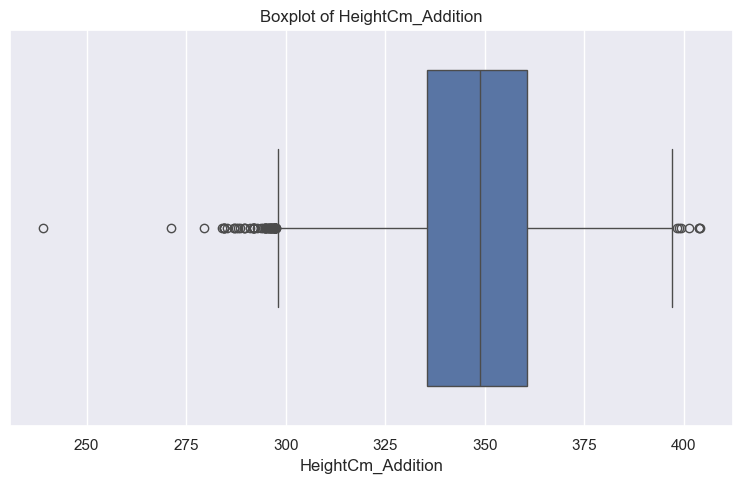

In [30]:
# boxplot
uv.plot_box(df, new, orientation='h')

#### WeightKg

In [31]:
# examine features
features = uf.get_feature_list(df, 'WeightKg')

                count       mean        std   min   25%   50%   75%    max
WeightKg_CAN  28744.0  83.404634  18.115061  29.9  70.4  82.6  95.7  165.1
WeightKg_DON  28747.0  83.561332  19.553094  23.2  70.0  80.8  94.1  198.0

:::: NaN Count:
WeightKg_CAN    7
WeightKg_DON    4


In [32]:
# new feature
df['WeightKg_Addition'] = df.WeightKg_CAN + df.WeightKg_DON

# initialize list
new = ['WeightKg_Addition']

# update DataFrame
df_drop  = uf.insert_into_dataframe(df_drop, features)
df_numeric =  uf.insert_into_dataframe(df_numeric, new)
df_new =  uf.insert_into_dataframe(df_new, new)
df_both = uf.insert_into_dataframe(df_both, new)

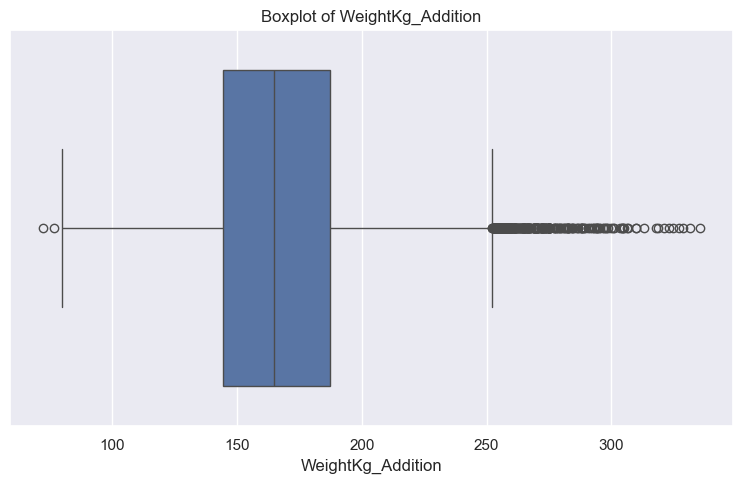

In [33]:
uv.plot_box(df, new, orientation='h')

In [34]:
# examine features
features = uf.get_feature_list(df, 'BMI_')

           count       mean       std        min        25%        50%        75%        max
BMI_CAN  28738.0  27.507774  4.872784  15.000000  23.900000  27.300000  31.000000  48.700000
BMI_DON  28741.0  27.603602  6.064300  13.121499  23.384354  26.555861  30.679328  74.360965

:::: NaN Count:
BMI_CAN    13
BMI_DON    10


In [35]:
df['BMI_CAN'] = df.WeightKg_CAN / np.square(df.HeightCm_CAN * 0.01)
df['BMI_DON'] = df.WeightKg_DON / np.square(df.HeightCm_DON * 0.01)

In [36]:
# create new feature
df['BMI_Addition'] = df.BMI_CAN + df.BMI_DON

# initialize list
new = ['BMI_Addition']

# update dataframe
df_drop  = uf.insert_into_dataframe(df_drop, features)
df_numeric = uf.insert_into_dataframe(df_numeric, new)
df_new = uf.insert_into_dataframe(df_new, new)
df_both = uf.insert_into_dataframe(df_both, new)

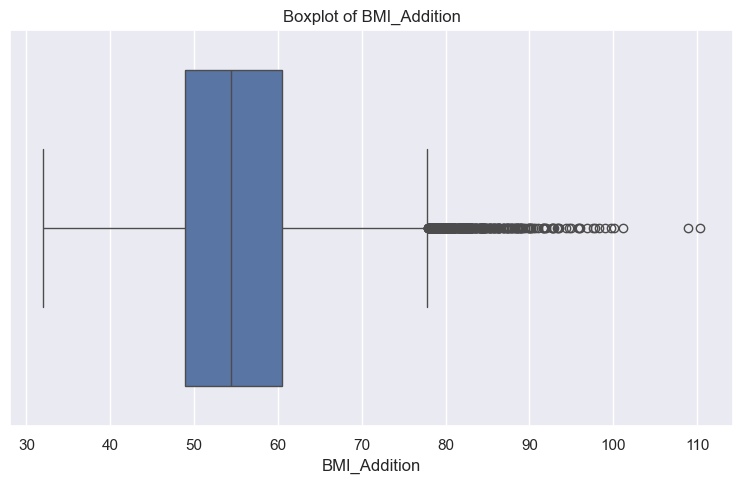

In [37]:
# boxplot
uv.plot_box(df, new, orientation='h')

##### BloodPH (Categorical)
- The normal blood pH range is indeed between 7.35 and 7.45. This slightly alkaline range is crucial for the proper functioning of enzymes and other biochemical reactions in the body.
    - A blood pH below 7.35 is considered acidic, and it can lead to a condition called acidosis. Acidosis can disrupt cellular functions and impair organ systems, particularly the cardiovascular and respiratory systems.
    - A blood pH above 7.45 is considered alkaline, and it can lead to a condition called alkalosis. Alkalosis can cause symptoms such as muscle twitching, hand tremors, and confusion.

In [38]:
# examine features
features = uf.get_feature_list(df, 'BloodPH')

               count   mean       std  min   25%   50%   75%   max
BloodPH_DON  28521.0  7.416  0.073821  5.0  7.38  7.42  7.46  7.93

:::: NaN Count:
BloodPH_DON    230


In [39]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
213,BloodPH_DON,DDR:Blood PH:,DDR,2004-06-30,NaT,CLINICAL INFORMATION,NUM,,,PH_DON,Numeric,


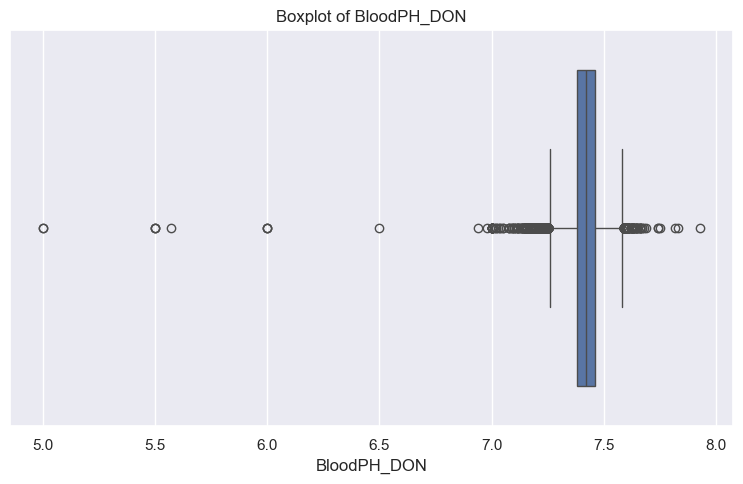

In [40]:
uv.plot_box(df, features, orientation='h')

##### [BloodUreaNitrogenLevel](https://www.frontiersin.org/journals/cardiovascular-medicine/articles/10.3389/fcvm.2023.1189884/full)
- Blood Urea Nitrogen (BUN) is a common blood test that measures the amount of urea nitrogen in the blood, which is a waste product formed from the breakdown of proteins.
    - Generally accepted range: 7 to 20 mg/dL (milligrams per deciliter).
    - Some sources report a slightly broader range of 6 to 24 mg/dL for adult men and 6 to 21 mg/dL for adult women. 

In [41]:
# examine features
features = uf.get_feature_list(df, 'BloodUreaNitrogenLevel')

                              count       mean        std  min   25%   50%   75%    max
BloodUreaNitrogenLevel_DON  28546.0  23.991873  19.930901  0.5  12.0  18.0  28.0  250.0

:::: NaN Count:
BloodUreaNitrogenLevel_DON    205


In [42]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
21,BloodUreaNitrogenLevel_DON,DECEASED DONOR-TERMINAL BLOOD UREA NITROGEN,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,BUN_DON,Numeric,


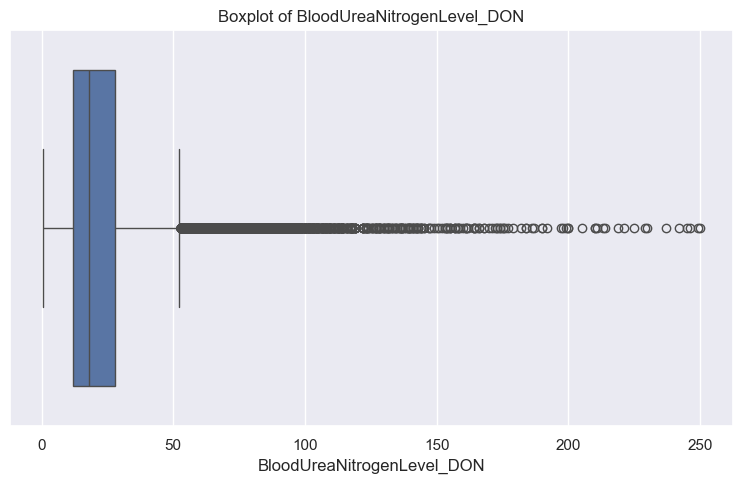

In [43]:
uv.plot_box(df, features, orientation='h')

##### [Creatinine](https://www.sciencedirect.com/science/article/pii/S0021915014013677?casa_token=ocgbMx1y4ikAAAAA:D0hbOvHvY45rjRH_LgJg62mSRUEu3ky2vZnuyhnyaP6xOphaF8WTWZ2TQ5KqGcNZi0xNrsLvunbZ)
- Creatinine levels can be affected by various health issues, including heart conditions. Generally, high creatinine levels are more common and often indicate that the kidneys are not functioning pr?operly. This can be due to conditions such as chronic kidney disease, dehydration, or even heart failure. When the heart is not pumping efficiently, it can lead to reduced blood flow to the kidneys, causing an increase in creatinine levels.

In [44]:
# examine features
features = uf.get_feature_list(df, 'Creatinine')

                              count      mean       std   min   25%  50%   75%   max
CreatinineRegistration_CAN  28604.0  1.363390  0.959501  0.08  0.94  1.2  1.50  24.0
CreatinineTransplant_CAN    28330.0  1.372100  1.001949  0.06  0.94  1.2  1.50  37.0
Creatinine_DON              28546.0  1.496195  1.543989  0.04  0.76  1.0  1.48  23.0

:::: NaN Count:
CreatinineRegistration_CAN    147
CreatinineTransplant_CAN      421
Creatinine_DON                205


In [45]:
df[features].corr()

,CreatinineRegistration_CAN,CreatinineTransplant_CAN,Creatinine_DON
CreatinineRegistration_CAN,1.000000,0.672968,-0.036554
CreatinineTransplant_CAN,0.672968,1.000000,-0.023086
Creatinine_DON,-0.036554,-0.023086,1.000000


In [46]:
# create new feature if non of the row contain NaN
df['Creatinine_Addition'] = df[features].apply(lambda row: row.sum() if row.notna().all() else np.nan, axis=1)
# initialize list
new = ['Creatinine_Addition']

# update DataFrame
df_drop  = uf.insert_into_dataframe(df_drop, features)
df_numeric =  uf.insert_into_dataframe(df_numeric, new)
df_new =  uf.insert_into_dataframe(df_new, new)
df_both = uf.insert_into_dataframe(df_both, new)

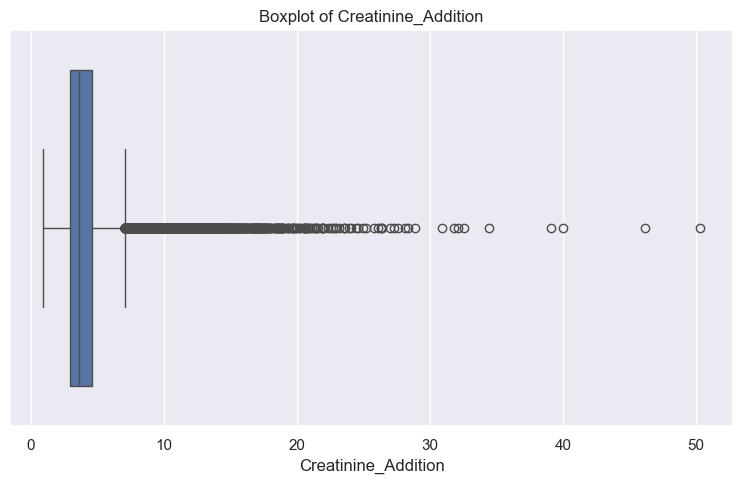

In [47]:
# boxplot
uv.plot_box(df, new, orientation='h')

In [48]:
# examine features
features = uf.get_feature_list(df, 'Creatinine')

                              count      mean       std   min   25%  50%   75%   max
CreatinineRegistration_CAN  28604.0  1.363390  0.959501  0.08  0.94  1.2  1.50  24.0
CreatinineTransplant_CAN    28330.0  1.372100  1.001949  0.06  0.94  1.2  1.50  37.0
Creatinine_Addition         28192.0  4.229285  2.326355  0.91  2.98  3.6  4.61  50.3
Creatinine_DON              28546.0  1.496195  1.543989  0.04  0.76  1.0  1.48  23.0

:::: NaN Count:
CreatinineRegistration_CAN    147
CreatinineTransplant_CAN      421
Creatinine_Addition           559
Creatinine_DON                205


##### DistanceFromDonorHospitaltoTXCenter

In [49]:
# examine features
features = uf.get_feature_list(df, 'DistanceFromDonorHospitaltoTXCenter')

                                       count        mean         std  min   25%    50%    75%     max
DistanceFromDonorHospitaltoTXCenter  28751.0  200.200097  221.177082  0.0  20.0  126.0  321.0  2215.0

:::: NaN Count:
DistanceFromDonorHospitaltoTXCenter    0


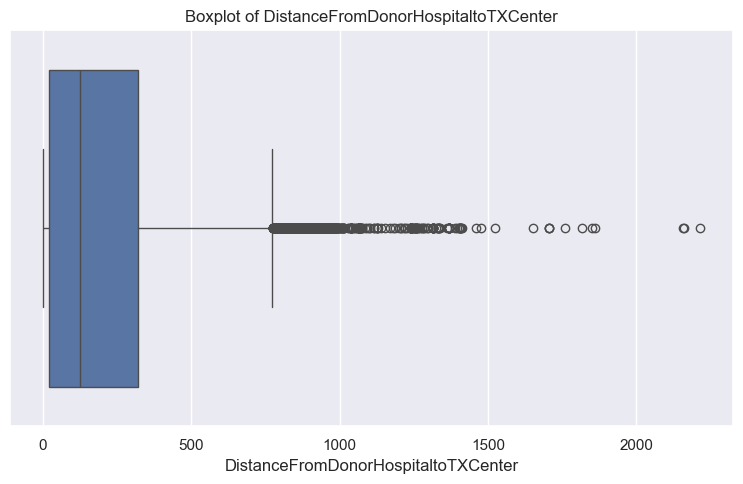

In [50]:
# boxplot
uv.plot_box(df, features, orientation='h')

##### Hematocrit
- Hematocrit is a blood test that measures the percentage of red blood cells (RBCs) in the total blood volume. It is an important indicator of overall health and can help diagnose various medical conditions.
    - Normal Hematocrit Ranges
        - Men: 38.3% to 48.6%
        - Women: 35.5% to 44.9% 

In [51]:
# examine features
features = uf.get_feature_list(df, 'Hematocrit')

                  count       mean       std  min   25%   50%   75%   max
Hematocrit_DON  28546.0  28.433506  5.001157  2.3  25.0  28.0  31.3  75.0

:::: NaN Count:
Hematocrit_DON    205


In [52]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
127,Hematocrit_DON,DDR:Hematocrit:,DDR,2004-06-30,NaT,CLINICAL INFORMATION,NUM,,,HEMATOCRIT_DON,Numeric,


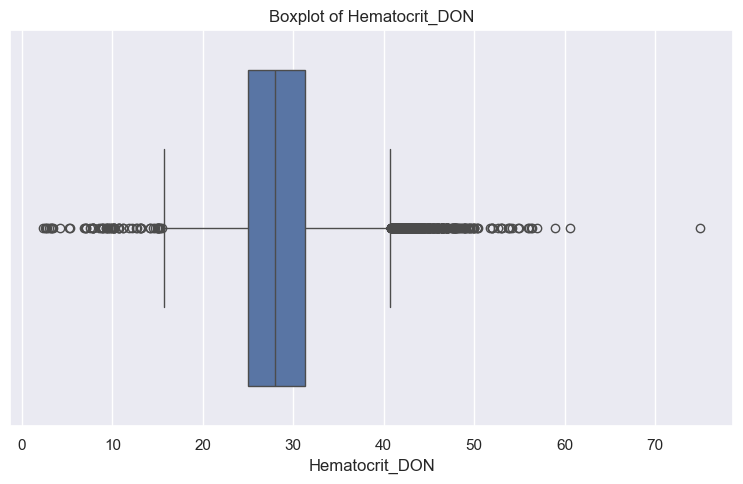

In [53]:
uv.plot_box(df, features, orientation='h')

##### Hemodynamics
- Hemodynamics refers to the study of blood flow and the forces involved in the circulatory system. It encompasses the physical principles governing blood movement through vessels and the heart, as well as the mechanics of blood flow and pressure regulation.
    - Here are some key ways hemodynamics can be affected:
        - Heart Failure: In heart failure, the heart's ability to pump blood effectively is compromised. This can lead to increased pressure in the heart and blood vessels, causing fluid buildup in the lungs and other tissues.
        - Valvular Heart Disease: Conditions like aortic stenosis or mitral regurgitation affect the flow of blood through the heart valves. This can lead to abnormal pressure gradients and changes in blood flow patterns, which can be detected through hemodynamic measurements.
        - Cardiomyopathies: These diseases affect the heart muscle, leading to changes in the heart's structure and function. Hemodynamic changes in cardiomyopathies can include altered cardiac output and increased filling pressures.
        - Hypertension: High blood pressure increases the workload on the heart, leading to changes in hemodynamics such as increased systemic vascular resistance and altered cardiac output1.
        - Pericardial Disease: Conditions like pericarditis or pericardial effusion can restrict the heart's movement, affecting hemodynamics by increasing pressures within the heart chambers and reducing cardiac output.

    - Hemodynamics:
        - Hemodynamics_SYS_CAN: Systolic blood pressure. (mmHg)
        - Hemodynamics_PA_DIA_CAN: Pulmonary artery diastolic pressure. (mmHg)
        - Hemodynamics_PA_MN_CAN: Pulmonary artery mean pressure. (mmHg)
        - Hemodynamics_PCW_CAN: Pulmonary capillary wedge pressure. (mmHg)
        - Hemodynamics_CO_CAN: Cardiac output. (L/min)

In [54]:
# examine features
features = uf.get_feature_list(df, 'Hemodynamics')

                                       count       mean        std   min    25%    50%    75%    max
HemodynamicsRegistration_CO_CAN      27092.0   4.266872   1.345663  0.39   3.33   4.11   5.00   15.0
HemodynamicsRegistration_PA_DIA_CAN  27692.0  20.529113   8.688313  0.00  14.00  20.00  26.00   91.0
HemodynamicsRegistration_PA_MN_CAN   27426.0  28.657685  10.213014  0.00  21.00  28.00  36.00   96.0
HemodynamicsRegistration_PCW_CAN     26023.0  19.142739   8.802624  0.00  12.00  19.00  25.00   50.0
HemodynamicsRegistration_SYS_CAN     27713.0  42.056400  14.254475  0.00  31.00  41.00  52.00  130.0
HemodynamicsTransplant_CO_CAN        27142.0   4.537917   1.457784  0.20   3.51   4.40   5.36   15.0
HemodynamicsTransplant_PA_DIA_CAN    27582.0  19.144776   8.476800  0.00  13.00  18.00  25.00  110.0
HemodynamicsTransplant_PA_MN_CAN     27320.0  27.004952   9.922125  0.00  20.00  26.00  34.00  110.0
HemodynamicsTransplant_PCW_CAN       26326.0  17.764157   8.676076  0.00  11.00  17.00  24.

In [55]:
df[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.212275,-0.188223,-0.233193,-0.148357,0.508997,-0.099349,-0.084288,-0.104403,-0.065083
HemodynamicsRegistration_PA_DIA_CAN,-0.212275,1.000000,0.893479,0.823933,0.786575,-0.069231,0.519014,0.504899,0.456370,0.455086
HemodynamicsRegistration_PA_MN_CAN,-0.188223,0.893479,1.000000,0.837968,0.918693,-0.049440,0.495646,0.550640,0.462904,0.529963
HemodynamicsRegistration_PCW_CAN,-0.233193,0.823933,0.837968,1.000000,0.763577,-0.075012,0.464893,0.484381,0.543227,0.446195
HemodynamicsRegistration_SYS_CAN,-0.148357,0.786575,0.918693,0.763577,1.000000,-0.031109,0.448326,0.530518,0.424563,0.573206
HemodynamicsTransplant_CO_CAN,0.508997,-0.069231,-0.049440,-0.075012,-0.031109,1.000000,-0.218352,-0.186911,-0.221604,-0.156447
HemodynamicsTransplant_PA_DIA_CAN,-0.099349,0.519014,0.495646,0.464893,0.448326,-0.218352,1.000000,0.901245,0.820000,0.791405
HemodynamicsTransplant_PA_MN_CAN,-0.084288,0.504899,0.550640,0.484381,0.530518,-0.186911,0.901245,1.000000,0.832616,0.917218
HemodynamicsTransplant_PCW_CAN,-0.104403,0.456370,0.462904,0.543227,0.424563,-0.221604,0.820000,0.832616,1.000000,0.761240
HemodynamicsTransplant_SYS_CAN,-0.065083,0.455086,0.529963,0.446195,0.573206,-0.156447,0.791405,0.917218,0.761240,1.000000


In [56]:
# examine features
features = uf.get_feature_list(df, 'Hemodynamics')

                                       count       mean        std   min    25%    50%    75%    max
HemodynamicsRegistration_CO_CAN      27092.0   4.266872   1.345663  0.39   3.33   4.11   5.00   15.0
HemodynamicsRegistration_PA_DIA_CAN  27692.0  20.529113   8.688313  0.00  14.00  20.00  26.00   91.0
HemodynamicsRegistration_PA_MN_CAN   27426.0  28.657685  10.213014  0.00  21.00  28.00  36.00   96.0
HemodynamicsRegistration_PCW_CAN     26023.0  19.142739   8.802624  0.00  12.00  19.00  25.00   50.0
HemodynamicsRegistration_SYS_CAN     27713.0  42.056400  14.254475  0.00  31.00  41.00  52.00  130.0
HemodynamicsTransplant_CO_CAN        27142.0   4.537917   1.457784  0.20   3.51   4.40   5.36   15.0
HemodynamicsTransplant_PA_DIA_CAN    27582.0  19.144776   8.476800  0.00  13.00  18.00  25.00  110.0
HemodynamicsTransplant_PA_MN_CAN     27320.0  27.004952   9.922125  0.00  20.00  26.00  34.00  110.0
HemodynamicsTransplant_PCW_CAN       26326.0  17.764157   8.676076  0.00  11.00  17.00  24.

In [57]:
# create new feature if non of the row contain NaN
df['Hemodynamics_Addition_CAN'] = df[features].apply(lambda row: row.sum() if row.notna().all() else np.nan, axis=1)

# initialize list
featuresD = ['Hemodynamics_Addition_CAN']

In [58]:
df[features + featuresD].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN,Hemodynamics_Addition_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.212275,-0.188223,-0.233193,-0.148357,0.508997,-0.099349,-0.084288,-0.104403,-0.065083,-0.143760
HemodynamicsRegistration_PA_DIA_CAN,-0.212275,1.000000,0.893479,0.823933,0.786575,-0.069231,0.519014,0.504899,0.456370,0.455086,0.820724
HemodynamicsRegistration_PA_MN_CAN,-0.188223,0.893479,1.000000,0.837968,0.918693,-0.049440,0.495646,0.550640,0.462904,0.529963,0.870608
HemodynamicsRegistration_PCW_CAN,-0.233193,0.823933,0.837968,1.000000,0.763577,-0.075012,0.464893,0.484381,0.543227,0.446195,0.799715
HemodynamicsRegistration_SYS_CAN,-0.148357,0.786575,0.918693,0.763577,1.000000,-0.031109,0.448326,0.530518,0.424563,0.573206,0.850511
HemodynamicsTransplant_CO_CAN,0.508997,-0.069231,-0.049440,-0.075012,-0.031109,1.000000,-0.218352,-0.186911,-0.221604,-0.156447,-0.116464
HemodynamicsTransplant_PA_DIA_CAN,-0.099349,0.519014,0.495646,0.464893,0.448326,-0.218352,1.000000,0.901245,0.820000,0.791405,0.812667
HemodynamicsTransplant_PA_MN_CAN,-0.084288,0.504899,0.550640,0.484381,0.530518,-0.186911,0.901245,1.000000,0.832616,0.917218,0.867466
HemodynamicsTransplant_PCW_CAN,-0.104403,0.456370,0.462904,0.543227,0.424563,-0.221604,0.820000,0.832616,1.000000,0.761240,0.785713
HemodynamicsTransplant_SYS_CAN,-0.065083,0.455086,0.529963,0.446195,0.573206,-0.156447,0.791405,0.917218,0.761240,1.000000,0.845980


In [59]:
# update DataFrame
df_drop  = uf.insert_into_dataframe(df_drop, features)
df_numeric =  uf.insert_into_dataframe(df_numeric, featuresD)
df_new =  uf.insert_into_dataframe(df_new, featuresD)
df_can = uf.insert_into_dataframe(df_can, featuresD)

##### [IschemicTimeHour](https://www.sciencedirect.com/science/article/pii/S0041134513004715)
- Ischemic time refers to the period during which an organ or tissue is deprived of blood supply and, consequently, oxygen. This concept is crucial in various medical contexts, particularly in transplantation and acute medical conditions like strokes and heart attacks.
    - Importance in Transplantation
        - Kidney: Optimal cold ischemic time is less than 20 hours, with suboptimal times extending beyond 36 hours.
        - Liver: Optimal cold ischemic time is less than 10 hours.
        - Heart: Optimal cold ischemic time is less than 4 hours.
        - Lung: Optimal cold ischemic time is less than 8 hours1.
    - Clinical Implications
        - Prolonged ischemic times can lead to greater tissue damage and delayed organ function.
        - Shorter ischemic times are associated with better transplant outcomes and long-term success

In [60]:
# examine features
features = uf.get_feature_list(df, 'IschemicTimeHour_DON')

                        count      mean       std  min  25%  50%  75%   max
IschemicTimeHour_DON  28187.0  3.233434  1.070273  0.3  2.5  3.3  3.9  12.0

:::: NaN Count:
IschemicTimeHour_DON    564


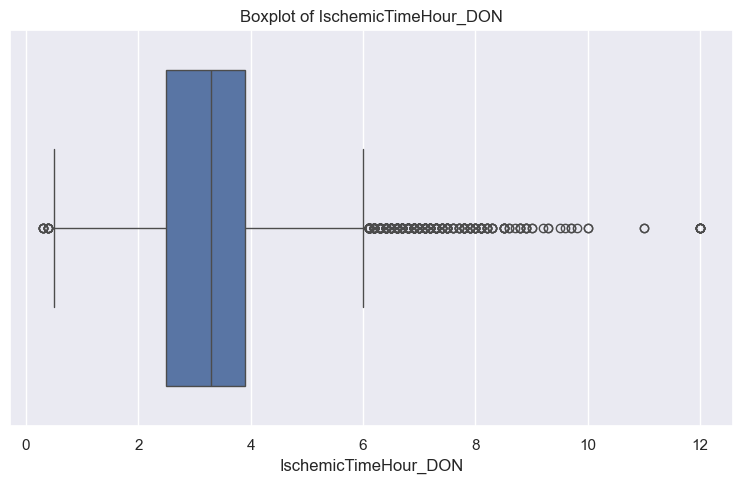

In [61]:
uv.plot_box(df, features)

##### LV_EjectionFractionPercent
- Left ventricular ejection fraction (LVEF) is a critical measurement used to assess the function of the heart, particularly in the context of organ donation and transplantation. It represents the percentage of blood that is pumped out of the left ventricle with each heartbeat.
    - Normal LVEF: Typically, a normal ejection fraction is between 50% and 70%.
    - Mildly Reduced LVEF: Values between 41% and 49% may indicate mild dysfunction.
    - Reduced LVEF: An LVEF less than 40% is often considered significantly reduced and may be a contraindication for organ donation, although recent studies suggest that donor hearts with reduced LVEF can still be viable for transplantation under certain conditions.

In [62]:
# examine features
features = uf.get_feature_list(df, 'LV_EjectionFractionPercent')

                                  count       mean       std   min   25%   50%   75%   max
LV_EjectionFractionPercent_DON  28718.0  61.618541  6.660556  10.0  56.0  60.0  65.0  99.0

:::: NaN Count:
LV_EjectionFractionPercent_DON    33


In [63]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
195,LV_EjectionFractionPercent_DON,DECEASED DONOR LV EJECTION FRACTION %,DDR,1999-10-25,NaT,HEART DONOR'S CARDIAC FUNCTION,NUM,,,LV_EJECT,Numeric,


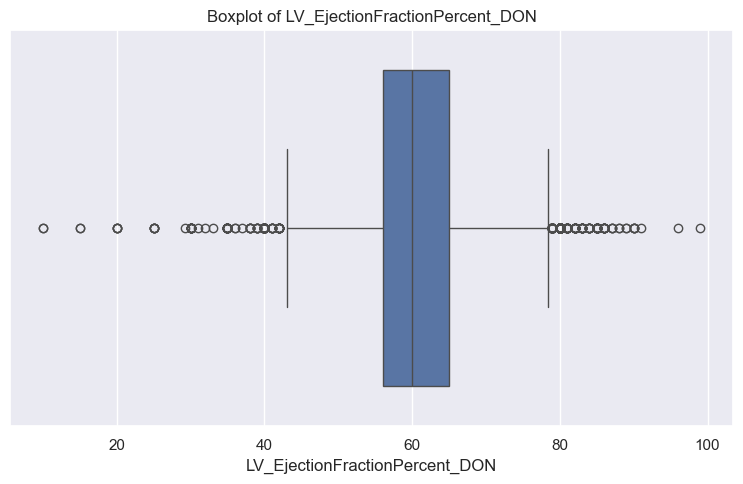

In [64]:
uv.plot_box(df, features, orientation='h')

##### [Level_SGOT](https://www.mdpi.com/2073-4409/9/3/567)
- SGOT (AST) and ALT (DON) are enzymes that are commonly measured to assess liver health:
    - SGOT (AST): Also known as aspartate aminotransferase (AST), this enzyme is found in various tissues, including the liver, heart, muscles, and kidneys. It plays a role in amino acid metabolism. Elevated levels of AST in the blood can indicate liver damage, heart problems, or muscle injury.
        - Conservative normal range of 8 to 45 units/L for healthy individuals. 
    - SGOT (ALT): Also known as alanine aminotransferase (ALT), this enzyme is primarily found in the liver. It helps convert proteins into energy for liver cells. High levels of ALT are more specific to liver damage compared to AST.
        - The typical normal range for ALT is approximately 7 to 56 units per liter (U/L) of serum. However, ranges may vary slightly between laboratories. 

In [65]:
# examine features
features = uf.get_feature_list(df, 'Level_SGOT')

                      count        mean         std  min   25%   50%   75%      max
Level_SGOT_ALT_DON  28541.0  114.102099  404.318823  3.0  23.0  41.0  83.0  44117.0
Level_SGOT_AST_DON  28541.0  101.952167  300.421156  0.3  26.0  44.0  87.0  10254.0

:::: NaN Count:
Level_SGOT_ALT_DON    210
Level_SGOT_AST_DON    210


In [66]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
259,Level_SGOT_AST_DON,DECEASED DONOR-TERMINAL SGOT/AST,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,SGOT_DON,Numeric,
260,Level_SGOT_ALT_DON,DECEASED DONOR-TERMINAL SGPT/ALT,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,SGPT_DON,Numeric,


In [67]:
df[features].corr()

,Level_SGOT_ALT_DON,Level_SGOT_AST_DON
Level_SGOT_ALT_DON,1.000000,0.561914
Level_SGOT_AST_DON,0.561914,1.000000


##### Addition can help you understand the combined enzyme activity. Capturing the overall level of these enzymes might be helpful.

In [68]:
# new feature
df['Level_SGOT_Addition_DON'] = df.Level_SGOT_ALT_DON + df.Level_SGOT_AST_DON

# initialize list
new = ['Level_SGOT_Addition_DON']

# update DataFrame
df_drop  = uf.insert_into_dataframe(df_drop, features)
df_numeric =  uf.insert_into_dataframe(df_numeric, new)
df_new =  uf.insert_into_dataframe(df_new, new)
df_both = uf.insert_into_dataframe(df_both, new)
df_don = uf.insert_into_dataframe(df_don, new)

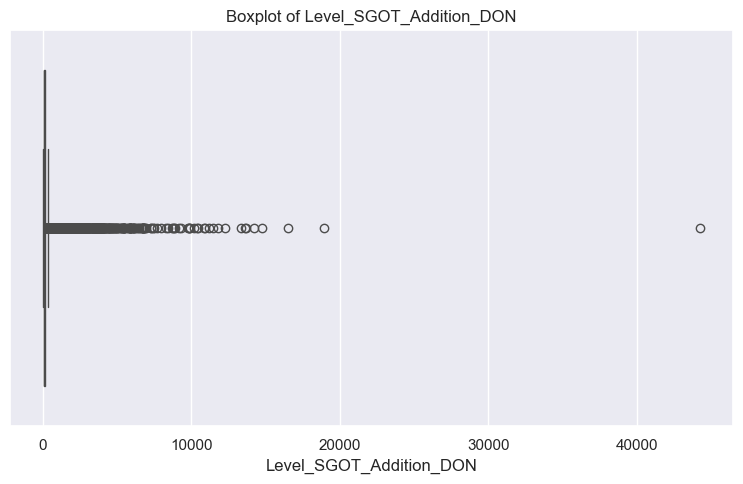

In [69]:
uv.plot_box(df, new, orientation='h')

##### LungPO2
    - Remove:
        - LungPO2_Done_DON 
- Lung PO2 (Partial Pressure of Oxygen) is a measure of the pressure exerted by oxygen in the lungs. It is an important indicator of how well oxygen is being transferred from the air in the lungs to the blood. The value of PO2 is typically measured in millimeters of mercury (mmHg) and provides insight into the efficiency of the respiratory system. In clinical and transplant contexts, particularly with donors, it helps assess the oxygenation status of the donor’s lungs, which is critical when evaluating organs for transplantation. `LungPO2_DON`: PO2 on 100% oxygen refers to the partial pressure of oxygen in arterial blood when a patient is breathing 100% oxygen.

- The Fraction of Inspired Oxygen (Lung FIO2) refers to the concentration of oxygen in the air that is being inhaled by a patient. It is a critical parameter in managing patients with respiratory distress and is often expressed as a percentage or as a decimal. `LungPO2_FIO2_DON`: Lung pO2 on FiO2 refers to the partial pressure of oxygen in arterial blood (PaO2) in relation to the fraction of inspired oxygen (FiO2).
    - Normal Range for FIO2
        - Room Air: The FIO2 in room air is approximately 21% or 0.21 as a decimal.
    - Supplemental Oxygen:
        - Low-Flow Oxygen Therapy: FIO2 can range from about 24% (0.24) to 40% (0.40), depending on the delivery device (e.g., nasal cannula, simple face mask).
        - High-Flow Oxygen Therapy: FIO2 can be set between 40% (0.40) and 100% (1.0), especially in more controlled environments like intensive care units.<br><br>

- The partial pressure of oxygen (PO2) levels can significantly impact heart conditions.
    - Low PO2 levels, or hypoxemia, can lead to insufficient oxygen in the blood, which stresses the heart as it works harder to supply oxygen to tissues1. This can exacerbate conditions like congestive heart failure.
    - To compensate for low oxygen levels, the heart may increase its rate and output, which can strain the heart over time2.
    - Even if blood oxygenation appears normal, poor cardiac output can result in inadequate oxygen delivery to tissues, leading to hypoxia. This can cause symptoms like chest pain, shortness of breath, and fatigue.
    - Interestingly, higher bilirubin levels, which can be influenced by PO2, have been associated with a reduced risk of cardiovascular diseases due to their antioxidant properties.

In [70]:
# examine features
features = uf.get_feature_list(df, 'LungPO2')

                    count unique      top   freq        mean         std   min    25%     50%      75%    max
LungPO2_DON       28504.0    NaN      NaN    NaN  280.746738  159.653759  7.38  131.0  256.15  425.025  698.0
LungPO2_Done_DON    28751      3  Missing  20025         NaN         NaN   NaN    NaN     NaN      NaN    NaN
LungPO2_FIO2_DON  28425.0    NaN      NaN    NaN    82.11803   25.544685   1.0   60.0   100.0    100.0  100.0

:::: NaN Count:
LungPO2_DON         247
LungPO2_Done_DON      0
LungPO2_FIO2_DON    326


In [71]:
df.LungPO2_Done_DON.value_counts(dropna=False)

LungPO2_Done_DON
Missing    20025
Yes         8690
No            36
Name: count, dtype: int64

In [72]:
# remove feature
features.remove('LungPO2_Done_DON')
# corr
df[features].corr()

,LungPO2_DON,LungPO2_FIO2_DON
LungPO2_DON,1.000000,0.616264
LungPO2_FIO2_DON,0.616264,1.000000


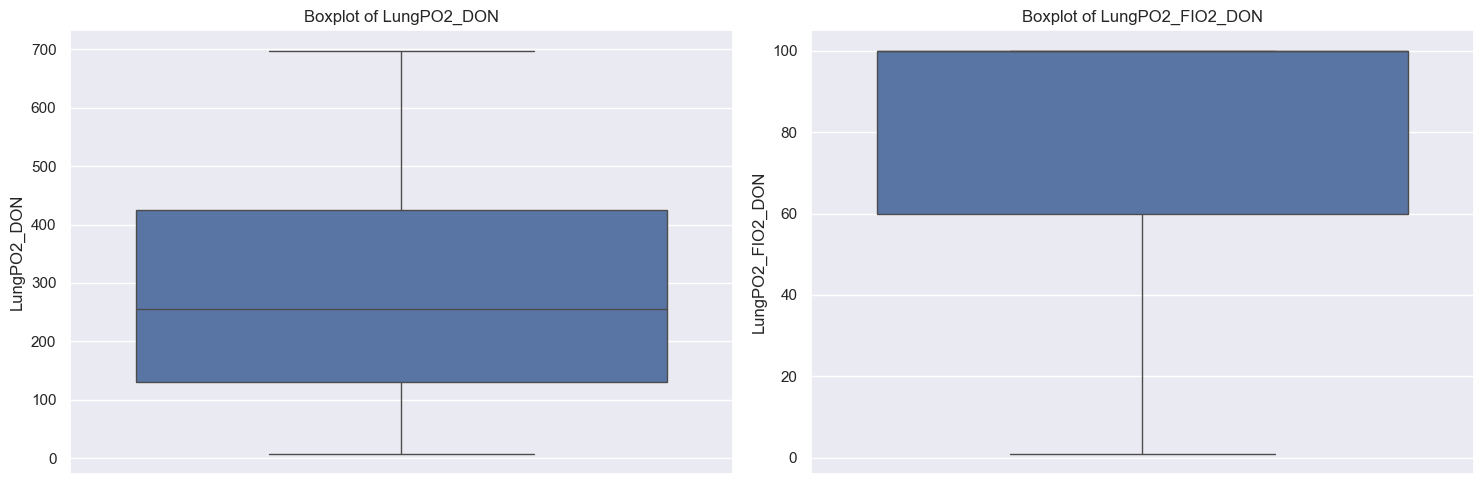

In [73]:
uv.plot_box(df, features, orientation='v')

##### OrganRecovery
- Normal `PCO2` Levels: The normal range for arterial blood `PCO2` is 35 to 45 mmHg (millimeters of mercury) or 4.7 to 6.0 kPa

In [74]:
# examine features
features = uf.get_feature_list(df, 'OrganRecovery')

                          count       mean      std   min   25%   50%   75%    max
OrganRecovery_PCO2_DON  28515.0  38.617131  7.06791  10.1  34.0  38.0  42.1  116.3

:::: NaN Count:
OrganRecovery_PCO2_DON    236


In [75]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
208,OrganRecovery_PCO2_DON,DDR:pCO2:,DDR,2004-06-30,NaT,ORGAN RECOVERY,NUM,,,PCO2_DON,Numeric,Maintaining appropriate PCO2 levels is crucial for preserving organ function and optimizing outcomes in transplantation.


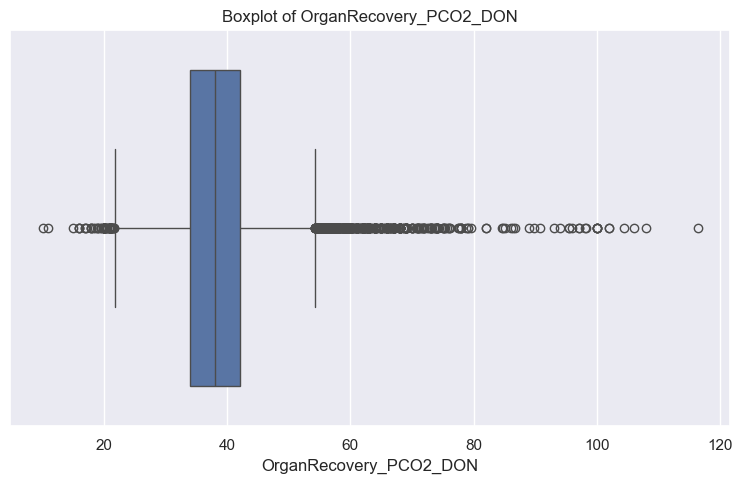

In [76]:
uv.plot_box(df, features, orientation='h')

##### [Bilirubin](https://www.mountsinai.org/health-library/tests/bilirubin-blood-test)
- Heart conditions can indeed influence total bilirubin levels, though the relationship is complex. Generally, higher bilirubin levels have been associated with a reduced risk of cardiovascular diseases (CVD). This is because bilirubin has antioxidant properties that may protect against oxidative stress and inflammation, which are key factors in the development of CVD. However, certain heart conditions, especially those that affect liver function or blood flow, could potentially lead to changes in bilirubin levels. For example, congestive heart failure can cause liver congestion, which might impair the liver's ability to process bilirubin, potentially leading to elevated levels.
- Bilirubin is a clinical measurement that evaluates the combined levels of direct (conjugated) and indirect (unconjugated) bilirubin in the blood. It is an important diagnostic marker for liver function, bile duct health, and conditions like jaundice.

In [77]:
# examine features
features = uf.get_feature_list(df, 'Bilirubin')

                                count      mean       std  min  25%  50%  75%   max
TerminalTotalBilirubin_DON    28542.0  1.043629  1.424194  0.0  0.5  0.7  1.1  45.4
TotalBilirubinTransplant_CAN  28289.0  0.993461  1.714805  0.1  0.5  0.7  1.1  80.0

:::: NaN Count:
TerminalTotalBilirubin_DON      209
TotalBilirubinTransplant_CAN    462


In [78]:
# new feature
df['TotalBilirubin_Addition'] = df.TotalBilirubinTransplant_CAN + df.TerminalTotalBilirubin_DON

# initialize list
new = ['TotalBilirubin_Addition']

# update DataFrame
df_drop  = uf.insert_into_dataframe(df_drop, features)
df_numeric =  uf.insert_into_dataframe(df_numeric, new)
df_new =  uf.insert_into_dataframe(df_new, new)
df_both = uf.insert_into_dataframe(df_both, new)

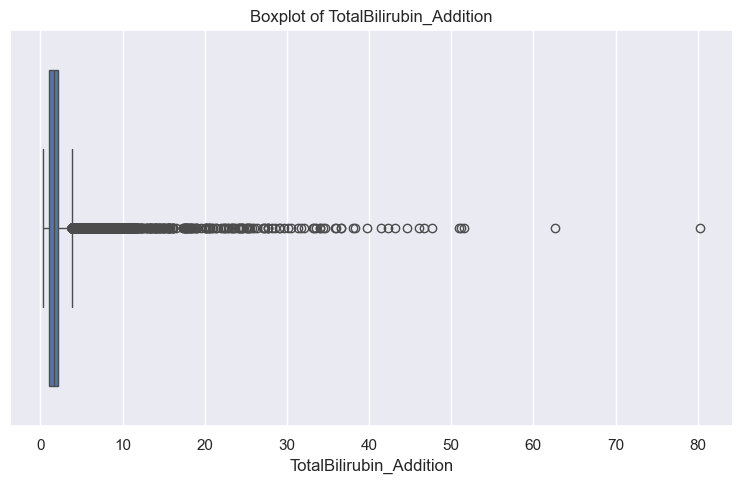

In [79]:
uv.plot_box(df, new, orientation='h')

##### TotalDayWaitList

In [80]:
# examine features
features = uf.get_feature_list(df, 'TotalDayWaitList')

                        count        mean       std  min   25%   50%    75%     max
TotalDayWaitList_CAN  28751.0  221.156551  376.9342  0.0  19.0  76.0  258.0  6412.0

:::: NaN Count:
TotalDayWaitList_CAN    0


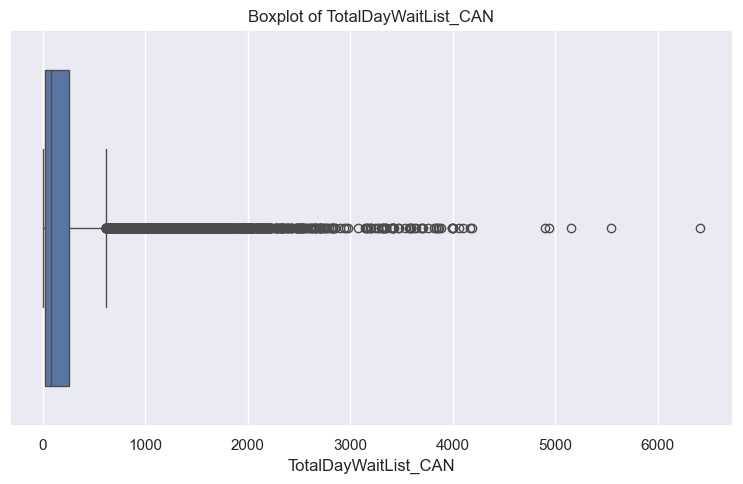

In [81]:
uv.plot_box(df, features, orientation='h')

### Nominal

In [82]:
# remove unused category
df = uf.remove_cat_zero_count(df).copy()

In [83]:
print(sorted(df_nominal.column.to_list()))

['AcuteRejectionEpisode', 'AirwayDehiscencePostTransplant', 'AllocationType_DON', 'AntiHypertensive_DON', 'AntibodyResultHBSAB_DON', 'AntibodyResultRPR_VDRL_DON', 'Antibody_HEP_C_DON', 'AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'ArginnieManagement_DON', 'Biopsy_DON', 'BloodGroupMatchLevel', 'BloodGroup_CAN', 'BloodGroup_DON', 'BloodInfectionSource_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CMVStatus_Transplant_CAN', 'CMV_IGG_Transplant_CAN', 'CMV_IGM_Transplant_CAN', 'CancerExtraCranial_DON', 'CancerHistory_DON', 'CancerIntraCranial_DON', 'CancerSkin_DON', 'CardiacArrest_DON', 'C

#### User Function(s)

In [84]:
def valuCounts(data, featuresList):
    for feature in featuresList:
        print(data[feature].value_counts(dropna=False).to_string())
        print('\n')

def genericMapCat(value):
    if value in ['Missing', 'Not Done', 'Indeterminate', 'UNKNOWN', 'Pending', 'Cannot Disclose']:
        return 'Unknown'
    else:
        return value


def antigenMapCat(value):
    if value in ['Not Tested','Unknown', 'Not Done']:
        return 'Unknown'
    elif value == '0':
        return 'Negative'
    else:
        return value  


def antigenCDR(value):
    if value in ['0', 'No second antigen detected']:
        return 'Negative'
    elif value in ['Missing', 'Not Done', 'Not Tested']:
        return 'Unknown'
    else:
        return 'Positive'


def bronchMapCat(value):
    if value in ['Missing','No Bronchoscopy','Unknown','Unknown if bronchoscopy performed']:
        return 'Unknown'
    elif value in ['Normal']:
        return value
    else:
        return 'Abnormal'


def cmvMapCat(value):
    if value in ['Indeterminate','Not Done','Missing']:
        return 'Unknown'
    else:
        return value


def xrayMapCat(value):
    if value in ['Missing', 'Results Unknown', 'No chest x-ray']:
        return 'Unknown'
    elif value in ['Normal']:
        return value
    else:
        return 'Abnormal'


def epsteinBarrMapCat(value):
    if value in ['Not Done','Indeterminate', 'Missing', 'Pending']:
        return 'Unknown'
    else:
        return value

##### AcuteRejectionEpisode (LABEL)

In [85]:
features = uf.get_feature_list(df, 'AcuteRejectionEpisode')

                       count unique top   freq
AcuteRejectionEpisode  28751      4  No  22908

:::: NaN Count:
AcuteRejectionEpisode    0


In [86]:
valuCounts(df, features)

AcuteRejectionEpisode
No                                                             22908
Yes, at least one episode treated with anti-rejection agent     2981
Yes, none treated with additional anti-rejection agent          2390
Missing                                                          472




In [87]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

AcuteRejectionEpisode
No                                                             22908
Yes, at least one episode treated with anti-rejection agent     2981
Yes, none treated with additional anti-rejection agent          2390
Unknown                                                          472




##### AirwayDehiscencePostTransplant

In [88]:
features = uf.get_feature_list(df, 'AirwayDehiscencePostTransplant')

                                count unique top   freq
AirwayDehiscencePostTransplant  28751      4  No  28069

:::: NaN Count:
AirwayDehiscencePostTransplant    0


In [89]:
valuCounts(df, features)

AirwayDehiscencePostTransplant
No         28069
Missing      464
Unknown      143
Yes           75




In [90]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

AirwayDehiscencePostTransplant
No         28069
Unknown      607
Yes           75




##### AllocationType_DON

In [91]:
features = uf.get_feature_list(df, 'AllocationType_DON')

                    count unique    top   freq
AllocationType_DON  28751      4  Local  14709

:::: NaN Count:
AllocationType_DON    0


In [92]:
valuCounts(df, features)

AllocationType_DON
Local            14709
National          8621
Regional          5394
Foreign Donor       27




##### AntiHypertensive_DON

In [93]:
features = uf.get_feature_list(df, 'AntiHypertensive_DON')

                      count unique top   freq
AntiHypertensive_DON  28751      4  No  19094

:::: NaN Count:
AntiHypertensive_DON    0


In [94]:
valuCounts(df, features)

AntiHypertensive_DON
No         19094
Yes         9442
Missing      206
Unknown        9




In [95]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

AntiHypertensive_DON
No         19094
Yes         9442
Unknown      215




##### Antibody Result

In [96]:
features = uf.get_feature_list(df, 'AntibodyResult')

                            count unique       top   freq
AntibodyResultHBSAB_DON     28751      7  Not Done  24420
AntibodyResultRPR_VDRL_DON  28751      4  Negative  27968

:::: NaN Count:
AntibodyResultHBSAB_DON       0
AntibodyResultRPR_VDRL_DON    0


In [97]:
valuCounts(df, features)

AntibodyResultHBSAB_DON
Not Done           24420
Negative            2565
Positive            1654
Indeterminate         60
Missing               45
Unknown                6
Cannot Disclose        1


AntibodyResultRPR_VDRL_DON
Negative    27968
Not Done      581
Positive      182
Missing        20




In [98]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

AntibodyResultHBSAB_DON
Unknown     24532
Negative     2565
Positive     1654


AntibodyResultRPR_VDRL_DON
Negative    27968
Unknown       601
Positive      182




##### Antibody_HEP

In [99]:
features = uf.get_feature_list(df, 'Antibody_HEP')

                    count unique       top   freq
Antibody_HEP_C_DON  28751      6  Negative  27299

:::: NaN Count:
Antibody_HEP_C_DON    0


In [100]:
valuCounts(df, features)

Antibody_HEP_C_DON
Negative         27299
Positive          1446
Missing              3
Indeterminate        1
Not Done             1
Pending              1




In [101]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Antibody_HEP_C_DON
Negative    27299
Positive     1446
Unknown         6




##### AntigenB

In [102]:
features = uf.get_feature_list(df, 'AntigenBW')

                count unique top   freq
AntigenBW4_CAN  28751      4   0  19615
AntigenBW6_CAN  28751      4   0  19269

:::: NaN Count:
AntigenBW4_CAN    0
AntigenBW6_CAN    0


In [103]:
valuCounts(df, features)

AntigenBW4_CAN
0           19615
Positive     6196
Negative     2932
Not Done        8


AntigenBW6_CAN
0           19269
Positive     8273
Negative     1208
Not Done        1




In [104]:
# remap
df[features] = df[features].map(antigenMapCat).fillna(df[features])
valuCounts(df, features)

AntigenBW4_CAN
Negative    22547
Positive     6196
Unknown         8


AntigenBW6_CAN
Negative    20477
Positive     8273
Unknown         1




##### AntigenC

In [105]:
features = uf.get_feature_list(df, 'AntigenC')

               count unique top   freq
AntigenC1_CAN  28751     37   0  19487
AntigenC2_CAN  28751     45   0  20340

:::: NaN Count:
AntigenC1_CAN    0
AntigenC2_CAN    0


In [106]:
valuCounts(df, features)

AntigenC1_CAN
0        19487
07        2006
04        1885
06         907
05         899
02         885
10         707
01         550
09         365
08         239
12         133
16          99
04:01       78
03:04       71
15          64
07:01       63
07:02       40
14          36
03:03       35
03          34
02:02       34
01:02       32
17          31
02:10       16
05:01       11
18           8
03:02        6
16:01        6
07:04        5
06:02        5
08:02        4
12:03        3
08:04        2
15:05        2
07:18        1
03:06        1
17:01        1


AntigenC2_CAN
0        20340
07        2359
16         764
10         634
12         623
06         615
08         542
04         488
15         399
17         398
05         376
09         304
14         205
18         129
07:02       92
07:01       89
02          81
16:01       53
04:01       41
12:03       37
01          31
08:02       26
17:01       19
14:02       16
03          14
15:02       12
07:04       12
03:04     

In [107]:
# remap
df[features] = df[features].map(antigenCDR).fillna(df[features])
valuCounts(df, features)

AntigenC1_CAN
Negative    19487
Positive     9264


AntigenC2_CAN
Negative    20340
Positive     8411




##### AntigenD

In [108]:
features = uf.get_feature_list(df, 'AntigenD')

                   count unique top   freq
AntigenDA1_DON     28751     41   2  11427
AntigenDA2_DON     28751     47  24   3191
AntigenDB1_DON     28751     83   7   5733
AntigenDB2_DON     28751     90  44   4099
AntigenDQ1_CAN     28751     25   0  19207
AntigenDQ2_CAN     28751     25   0  20339
AntigenDR1_DON     28751     44   4   7125
AntigenDR2_DON     28751     48  15   5978
AntigenDR51_2_CAN  28751      8   0  27180
AntigenDR51_CAN    28751      9   0  20736
AntigenDR52_2_CAN  28751     10   0  27085
AntigenDR52_CAN    28751     10   0  20131
AntigenDR53_2_CAN  28751      6   0  27173
AntigenDR53_CAN    28751      7   0  20469

:::: NaN Count:
AntigenDA1_DON       0
AntigenDA2_DON       0
AntigenDB1_DON       0
AntigenDB2_DON       0
AntigenDQ1_CAN       0
AntigenDQ2_CAN       0
AntigenDR1_DON       0
AntigenDR2_DON       0
AntigenDR51_2_CAN    0
AntigenDR51_CAN      0
AntigenDR52_2_CAN    0
AntigenDR52_CAN      0
AntigenDR53_2_CAN    0
AntigenDR53_CAN      0


In [109]:
valuCounts(df, features)

AntigenDA1_DON
2          11427
1           6476
3           3558
24          1709
11          1282
23          1039
30           762
29           492
26           374
31           269
33           267
25           225
68           213
32           185
02:01         93
34            85
36            64
01:01         56
66            45
03:01         32
11:01         16
24:02         15
74            15
24:03          9
30:01          5
02:06          4
02:05          4
29:02          4
02:03          4
33:03          3
Missing        3
02:02          3
34:02          2
10             2
68:02          2
26:01          2
28             1
01:02          1
66:01          1
03:02          1
69             1


AntigenDA2_DON
24                            3191
68                            3184
3                             2972
2                             2822
No second antigen detected    2436
30                            1840
11                            1701
29                        

In [110]:
# remap
df[features] = df[features].map(antigenCDR).fillna(df[features])
valuCounts(df, features)

AntigenDA1_DON
Positive    28748
Unknown         3


AntigenDA2_DON
Positive    26301
Negative     2437
Unknown        13


AntigenDB1_DON
Positive    28748
Unknown         3


AntigenDB2_DON
Positive    27440
Negative     1296
Unknown        15


AntigenDQ1_CAN
Negative    19207
Positive     9544


AntigenDQ2_CAN
Negative    20339
Positive     8412


AntigenDR1_DON
Positive    28746
Unknown         5


AntigenDR2_DON
Positive    26775
Negative     1959
Unknown        17


AntigenDR51_2_CAN
Negative    27180
Positive     1512
Unknown        59


AntigenDR51_CAN
Negative    20736
Positive     7847
Unknown       168


AntigenDR52_2_CAN
Negative    27085
Positive     1607
Unknown        59


AntigenDR52_CAN
Negative    20131
Positive     8458
Unknown       162


AntigenDR53_2_CAN
Negative    27173
Positive     1518
Unknown        60


AntigenDR53_CAN
Negative    20469
Positive     8111
Unknown       171




##### AntigenR

In [111]:
features = uf.get_feature_list(df, 'AntigenR')

                 count unique top  freq
AntigenRA1_CAN   28751     51   2  9635
AntigenRA2_CAN   28751     52  68  2647
AntigenRB1_CAN   28751    101   7  4874
AntigenRB2_CAN   28751     99  44  3497
AntigenRDR1_CAN  28751     54   4  5505
AntigenRDR2_CAN  28751     57  15  5562

:::: NaN Count:
AntigenRA1_CAN     0
AntigenRA2_CAN     0
AntigenRB1_CAN     0
AntigenRB2_CAN     0
AntigenRDR1_CAN    0
AntigenRDR2_CAN    0


In [112]:
valuCounts(df, features)

AntigenRA1_CAN
2             9635
1             5428
3             2955
Missing       2202
24            1562
11            1334
23            1190
30             862
29             500
02:01          393
33             355
26             338
01:01          257
0              251
68             210
32             193
25             186
31             184
34             121
03:01          109
36              70
24:02           61
66              59
11:01           54
74              33
02:02           23
02:05           22
30:01           19
02:03           17
33:03           17
26:01           16
29:02           15
30:02           14
10              10
68:02            7
34:02            7
24:03            6
68:01            5
28               5
02:06            5
33:01            4
03:02            3
01:02            3
66:01            2
66:02            2
80               2
02:07            1
69               1
210              1
29:01            1
Not Tested       1


AntigenRA2_CAN

In [113]:
# remap
df[features] = df[features].map(antigenCDR).fillna(df[features])
valuCounts(df, features)

AntigenRA1_CAN
Positive    26297
Unknown      2203
Negative      251


AntigenRA2_CAN
Positive    23862
Negative     2686
Unknown      2203


AntigenRB1_CAN
Positive    26298
Unknown      2203
Negative      250


AntigenRB2_CAN
Positive    25046
Unknown      2203
Negative     1502


AntigenRDR1_CAN
Positive    26297
Unknown      2204
Negative      250


AntigenRDR2_CAN
Positive    24502
Unknown      2204
Negative     2045




##### ArginnieManagement_DON

In [114]:
features = uf.get_feature_list(df, 'ArginnieManagement_DON')

                        count unique  top   freq
ArginnieManagement_DON  28751      4  Yes  19759

:::: NaN Count:
ArginnieManagement_DON    0


In [115]:
valuCounts(df, features)

ArginnieManagement_DON
Yes        19759
No          8779
Missing      206
Unknown        7




In [116]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

ArginnieManagement_DON
Yes        19759
No          8779
Unknown      213




##### Biopsy_DON

In [117]:
features = uf.get_feature_list(df, 'Biopsy_DON')

            count unique              top   freq
Biopsy_DON  28751      5  Biopsy not done  28514

:::: NaN Count:
Biopsy_DON    0


In [118]:
valuCounts(df, features)

Biopsy_DON
Biopsy not done                 28514
Missing                           206
Yes, rejection not confirmed       12
Yes, rejection confirmed           10
Unknown                             9




In [119]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Biopsy_DON
Biopsy not done                 28514
Unknown                           215
Yes, rejection not confirmed       12
Yes, rejection confirmed           10




##### BloodGroup

In [120]:
features = uf.get_feature_list(df, 'BloodGroup')

                      count unique        top   freq
BloodGroupMatchLevel  28751      3  Identical  24619
BloodGroup_CAN        28751      8          O  11367
BloodGroup_DON        28751      8          O  14640

:::: NaN Count:
BloodGroupMatchLevel    0
BloodGroup_CAN          0
BloodGroup_DON          0


In [121]:
valuCounts(df, features)

BloodGroupMatchLevel
Identical       24619
Compatible       4131
Incompatible        1


BloodGroup_CAN
O      11367
A      11325
B       4382
AB      1592
A1        69
A2         7
A1B        5
A2B        4


BloodGroup_DON
O      14640
A1      5132
A       4295
B       3192
A2       862
AB       303
A1B      234
A2B       93




##### Infection

In [122]:
features = uf.get_feature_list(df, 'Infection')

                          count unique  top   freq
BloodInfectionSource_DON  28751      3    0  25920
InfectionClinical_DON     28751      4  Yes  21856
InfectionTherapyIV_CAN    28751      4   No  25055
OtherInfectionSource_DON  28751      3    0  19772
PulmonaryInfection_DON    28751      3    1  19988
UrineInfection_DON        28751      3    0  25408

:::: NaN Count:
BloodInfectionSource_DON    0
InfectionClinical_DON       0
InfectionTherapyIV_CAN      0
OtherInfectionSource_DON    0
PulmonaryInfection_DON      0
UrineInfection_DON          0


In [123]:
valuCounts(df, features)

BloodInfectionSource_DON
0      25920
1       2828
999        3


InfectionClinical_DON
Yes        21856
No          6622
Missing      205
Unknown       68


InfectionTherapyIV_CAN
No         25055
Yes         2958
Missing      428
Unknown      310


OtherInfectionSource_DON
0      19772
999     6895
1       2084


PulmonaryInfection_DON
1      19988
0       8760
999        3


UrineInfection_DON
0      25408
1       3340
999        3




In [124]:
# convert to str
df[features] = df[features].astype(str)

# remap
for feature in features:
    df[feature] = df[feature].map({'0': 'No', '1': 'Yes', '999': 'Unknown', 'Missing': 'Unknown'}).fillna(df[feature])

# convert to category
df[features] = df[features].astype('category')
valuCounts(df, features)

BloodInfectionSource_DON
No         25920
Yes         2828
Unknown        3


InfectionClinical_DON
Yes        21856
No          6622
Unknown      273


InfectionTherapyIV_CAN
No         25055
Yes         2958
Unknown      738


OtherInfectionSource_DON
No         19772
Unknown     6895
Yes         2084


PulmonaryInfection_DON
Yes        19988
No          8760
Unknown        3


UrineInfection_DON
No         25408
Yes         3340
Unknown        3




##### Bronchoscopy

In [125]:
features = uf.get_feature_list(df, 'Bronchoscopy')

                       count unique      top   freq
BronchoscopyLeft_DON   28751      9  Missing  14314
BronchoscopyRight_DON  28751      9  Missing  14519

:::: NaN Count:
BronchoscopyLeft_DON     0
BronchoscopyRight_DON    0


In [126]:
valuCounts(df, features)

BronchoscopyLeft_DON
Missing                                14314
Normal                                 10294
Abnormal-purulent secretions            2164
Abnormal-blood                           936
No Bronchoscopy                          657
Abnormal-anatomy/other lesion            190
Abnormal-aspiration of foreign body      130
Unknown                                   52
Unknown if bronchoscopy performed         14


BronchoscopyRight_DON
Missing                                14519
Normal                                  9640
Abnormal-purulent secretions            2462
Abnormal-blood                          1006
No Bronchoscopy                          669
Abnormal-anatomy/other lesion            220
Abnormal-aspiration of foreign body      166
Unknown                                   58
Unknown if bronchoscopy performed         11




In [127]:
# remap
df[features] = df[features].map(bronchMapCat).fillna(df[features])
valuCounts(df, features)

BronchoscopyLeft_DON
Unknown     15037
Normal      10294
Abnormal     3420


BronchoscopyRight_DON
Unknown     15257
Normal       9640
Abnormal     3854




##### CMV

In [128]:
features = uf.get_feature_list(df, 'CMV')

                          count unique       top   freq
CMVStatus_Transplant_CAN  28751      5  Positive  16029
CMV_IGG_Transplant_CAN    28751      5   Missing  20187
CMV_IGM_Transplant_CAN    28751      5   Missing  20188
SerologyAntiCMV_DON       28751      6  Positive  17600

:::: NaN Count:
CMVStatus_Transplant_CAN    0
CMV_IGG_Transplant_CAN      0
CMV_IGM_Transplant_CAN      0
SerologyAntiCMV_DON         0


In [129]:
valuCounts(df, features)

CMVStatus_Transplant_CAN
Positive    16029
Negative    11813
Missing       407
Unknown       260
Not Done      242


CMV_IGG_Transplant_CAN
Missing     20187
Positive     5010
Negative     3359
Not Done      166
Unknown        29


CMV_IGM_Transplant_CAN
Missing     20188
Negative     5869
Not Done     2259
Positive      302
Unknown       133


SerologyAntiCMV_DON
Positive         17600
Negative         11009
Indeterminate      110
Not Done            22
Missing              9
Unknown              1




In [130]:
# add to list: No value
# removeCols.extend(['CMV_IGG_Transplant_CAN','CMV_IGM_Transplant_CAN'])
# remap
df[features] = df[features].map(cmvMapCat).fillna(df[features])
valuCounts(df, features)

CMVStatus_Transplant_CAN
Positive    16029
Negative    11813
Unknown       909


CMV_IGG_Transplant_CAN
Unknown     20382
Positive     5010
Negative     3359


CMV_IGM_Transplant_CAN
Unknown     22580
Negative     5869
Positive      302


SerologyAntiCMV_DON
Positive    17600
Negative    11009
Unknown       142




##### Cancer

In [131]:
features = uf.get_feature_list(df, 'Cancer')

                        count unique top   freq
CancerExtraCranial_DON  28751      4  No  28326
CancerHistory_DON       28751      4  No  28182
CancerIntraCranial_DON  28751      4  No  28302
CancerSite_DON          28751     27  NO  28182
CancerSkin_DON          28751      4  No  28352

:::: NaN Count:
CancerExtraCranial_DON    0
CancerHistory_DON         0
CancerIntraCranial_DON    0
CancerSite_DON            0
CancerSkin_DON            0


In [132]:
valuCounts(df, features)

CancerExtraCranial_DON
No         28326
Missing      207
Unknown      167
Yes           51


CancerHistory_DON
No         28182
Yes          374
Unknown      182
Missing       13


CancerIntraCranial_DON
No         28302
Missing      207
Unknown      182
Yes           60


CancerSite_DON
NO                                              28182
UNKNOWN                                           182
SKIN - SQUAMOUS, BASAL CELL                        87
OTHER, SPECIFY                                     73
GENITOURINARY - UTERINE CERVIX                     44
CNS TUMOR - MENINGIOMA                             19
CNS TUMOR - OTHER                                  19
GENITOURINARY - PENIS, TESTICULAR                  18
CNS TUMOR - ASTROCYTOMA                            17
THYROID                                            16
CNS TUMOR - GLIOBLASTOMA MULTIFORME                14
Missing                                            13
GENITOURINARY - OVARIAN                            12
BREAST   

In [133]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

CancerExtraCranial_DON
No         28326
Unknown      374
Yes           51


CancerHistory_DON
No         28182
Yes          374
Unknown      195


CancerIntraCranial_DON
No         28302
Unknown      389
Yes           60


CancerSite_DON
NO                                              28182
Unknown                                           195
SKIN - SQUAMOUS, BASAL CELL                        87
OTHER, SPECIFY                                     73
GENITOURINARY - UTERINE CERVIX                     44
CNS TUMOR - MENINGIOMA                             19
CNS TUMOR - OTHER                                  19
GENITOURINARY - PENIS, TESTICULAR                  18
CNS TUMOR - ASTROCYTOMA                            17
THYROID                                            16
CNS TUMOR - GLIOBLASTOMA MULTIFORME                14
GENITOURINARY - OVARIAN                            12
BREAST                                             11
SKIN - MELANOMA                                     8
LEUKEM

##### CardiacArrest_DON

In [134]:
features = uf.get_feature_list(df, 'CardiacArrest_DON')

                   count unique top   freq
CardiacArrest_DON  28751      3  No  26165

:::: NaN Count:
CardiacArrest_DON    0


In [135]:
valuCounts(df, features)

CardiacArrest_DON
No         26165
Yes         2073
Missing      513




In [136]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

CardiacArrest_DON
No         26165
Yes         2073
Unknown      513




##### Cause of Death

In [137]:
features = uf.get_feature_list(df, 'Death')

                       count unique                        top   freq
CauseOfDeath_DON       28751      6                HEAD TRAUMA  13210
DeathCircumstance_DON  28751      8  DEATH FROM NATURAL CAUSES   6700
DeathMechanism_DON     28751     13               BLUNT INJURY   8046

:::: NaN Count:
CauseOfDeath_DON         0
DeathCircumstance_DON    0
DeathMechanism_DON       0


In [138]:
valuCounts(df, features)

CauseOfDeath_DON
HEAD TRAUMA               13210
ANOXIA                    10100
CEREBROVASCULAR/STROKE     4673
OTHER SPECIFY               636
CNS TUMOR                   128
Missing                       4


DeathCircumstance_DON
DEATH FROM NATURAL CAUSES    6700
MVA                          6264
Accident, Non-MVA            4937
SUICIDE                      4624
NONE OF THE ABOVE            3610
HOMICIDE                     2600
Missing                        15
CHILD-ABUSE                     1


DeathMechanism_DON
BLUNT INJURY                      8046
GUNSHOT WOUND                     5043
INTRACRANIAL HEMORRHAGE/STROKE    4955
DRUG INTOXICATION                 4808
CARDIOVASCULAR                    2457
ASPHYXIATION                      1720
DEATH FROM NATURAL CAUSES          593
NONE OF THE ABOVE                  545
SEIZURE                            281
DROWNING                           180
STAB                                76
ELECTRICAL                          39
Missin

##### CerebroVascularDisease_CAN

In [139]:
features = uf.get_feature_list(df, 'CerebroVascularDisease')

                            count unique top   freq
CerebroVascularDisease_CAN  28751      4  No  26646

:::: NaN Count:
CerebroVascularDisease_CAN    0


In [140]:
valuCounts(df, features)

CerebroVascularDisease_CAN
No         26646
Yes         1845
Unknown      183
Missing       77




In [141]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

CerebroVascularDisease_CAN
No         26646
Yes         1845
Unknown      260




##### ChestXray

In [142]:
features = uf.get_feature_list(df, 'ChestXray')

               count unique            top   freq
ChestXray_DON  28751      7  Abnormal-both  15292

:::: NaN Count:
ChestXray_DON    0


In [143]:
valuCounts(df, features)

ChestXray_DON
Abnormal-both      15292
Normal              5968
Abnormal-right      3394
Abnormal-left       2621
Missing             1405
Results Unknown       57
No chest x-ray        14




In [144]:
# remap
df[features] = df[features].map(xrayMapCat).fillna(df[features])
valuCounts(df, features)

ChestXray_DON
Abnormal    21307
Normal       5968
Unknown      1476




##### Cigarette

In [145]:
features = uf.get_feature_list(df, 'Cigarette')

                         count unique      top   freq
CigaretteAbstinence_CAN  28751     10  Missing  16169
CigaretteHistory_DON     28751      4       No  24978
CigaretteUse_CAN         28751      3       No  16093

:::: NaN Count:
CigaretteAbstinence_CAN    0
CigaretteHistory_DON       0
CigaretteUse_CAN           0


In [146]:
valuCounts(df, features)

CigaretteAbstinence_CAN
Missing               16169
>60 months             7159
3-12 months            2094
13-24 months            985
25-36 months            612
37-48 months            479
Unknown duration        453
49-60 months            416
0-2 months              331
Continues to smoke       53


CigaretteHistory_DON
No         24978
Yes         3299
Unknown      469
Missing        5


CigaretteUse_CAN
No         16093
Yes        12582
Missing       76




In [147]:
# remap
for feature in features:
    df[feature] = df[feature].map({'Missing': 'Unknown', 'Unknown duration': 'Unknown'}).fillna(df[feature])

valuCounts(df, features)

CigaretteAbstinence_CAN
Unknown               16622
>60 months             7159
3-12 months            2094
13-24 months            985
25-36 months            612
37-48 months            479
49-60 months            416
0-2 months              331
Continues to smoke       53


CigaretteHistory_DON
No         24978
Yes         3299
Unknown      474


CigaretteUse_CAN
No         16093
Yes        12582
Unknown       76




##### Citizenship

In [148]:
features = uf.get_feature_list(df, 'Citizenship')

                 count unique         top   freq
Citizenship_CAN  28751      7  US Citizen  27682
Citizenship_DON  28751      7  US Citizen  25901

:::: NaN Count:
Citizenship_CAN    0
Citizenship_DON    0


In [149]:
valuCounts(df, features)

Citizenship_CAN
US Citizen                                                                         27682
Non-US Citizen/US Resident                                                           758
Non-US Citizen/Non-US Resident, Traveled to US for Transplant                        114
Missing                                                                               72
Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant       70
RESIDENT ALIEN                                                                        45
NON-RESIDENT ALIEN                                                                    10


Citizenship_DON
US Citizen                                                                         25901
Unknown                                                                             1603
Non-US Citizen/US Resident                                                           893
Missing                                                                     

In [150]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Citizenship_CAN
US Citizen                                                                         27682
Non-US Citizen/US Resident                                                           758
Non-US Citizen/Non-US Resident, Traveled to US for Transplant                        114
Unknown                                                                               72
Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant       70
RESIDENT ALIEN                                                                        45
NON-RESIDENT ALIEN                                                                    10


Citizenship_DON
US Citizen                                                                         25901
Unknown                                                                             1805
Non-US Citizen/US Resident                                                           893
Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transpl

##### Cocaine & Drug

In [151]:
features = uf.get_feature_list(df, 'Cocaine|Drug')

                      count unique      top   freq
CocaineUse_DON        28751      4  Missing  22428
OtherDrugUse_DON      28751      4  Missing  12816
PastCocaineUse_DON    28751      4       No  21715
PastOtherDrugUse_DON  28751      4      Yes  15935

:::: NaN Count:
CocaineUse_DON          0
OtherDrugUse_DON        0
PastCocaineUse_DON      0
PastOtherDrugUse_DON    0


In [152]:
valuCounts(df, features)

CocaineUse_DON
Missing    22428
Yes         3307
No          2165
Unknown      851


OtherDrugUse_DON
Missing    12816
Yes        12073
No          2489
Unknown     1373


PastCocaineUse_DON
No         21715
Yes         6323
Unknown      507
Missing      206


PastOtherDrugUse_DON
Yes        15935
No         12301
Unknown      309
Missing      206




In [153]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

CocaineUse_DON
Unknown    23279
Yes         3307
No          2165


OtherDrugUse_DON
Unknown    14189
Yes        12073
No          2489


PastCocaineUse_DON
No         21715
Yes         6323
Unknown      713


PastOtherDrugUse_DON
Yes        15935
No         12301
Unknown      515




##### CoronaryAngiogram_DON

In [154]:
features = uf.get_feature_list(df, 'CoronaryAngiogram')

                       count unique top   freq
CoronaryAngiogram_DON  28751      4  No  18088

:::: NaN Count:
CoronaryAngiogram_DON    0


In [155]:
valuCounts(df, features)

CoronaryAngiogram_DON
No                 18088
Yes, normal         9541
Yes, not normal      913
Missing              209




In [156]:
# remap
for feature in features:
    df[feature] = df[feature].map({'Missing': 'Unknown', 'No': 'Unknown', 'Yes, normal': 'Normal', 'Yes, not normal': 'Abnormal'}).fillna(df[feature])

valuCounts(df, features)

CoronaryAngiogram_DON
Unknown     18297
Normal       9541
Abnormal      913




##### CrossMatchDone

In [157]:
features = uf.get_feature_list(df, 'CrossMatchDone')

                count unique  top   freq
CrossMatchDone  28751      3  Yes  26524

:::: NaN Count:
CrossMatchDone    0


In [158]:
valuCounts(df, features)

CrossMatchDone
Yes        26524
No          1561
Missing      666




In [159]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

CrossMatchDone
Yes        26524
No          1561
Unknown      666




##### DeceasedRetyped_DON

In [160]:
features = uf.get_feature_list(df, 'DeceasedRetyped')

                     count unique  top   freq
DeceasedRetyped_DON  28751      3  Yes  17177

:::: NaN Count:
DeceasedRetyped_DON    0


In [161]:
valuCounts(df, features)

DeceasedRetyped_DON
Yes        17177
No         10906
Missing      668




In [162]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

DeceasedRetyped_DON
Yes        17177
No         10906
Unknown      668




##### Defibrillator

In [163]:
features = uf.get_feature_list(df, 'Defibrillator')

                                      count unique  top   freq
DefibrillatorImplantRegistration_CAN  28751      4  Yes  21153

:::: NaN Count:
DefibrillatorImplantRegistration_CAN    0


In [164]:
valuCounts(df, features)

DefibrillatorImplantRegistration_CAN
Yes        21153
No          7160
Unknown      363
Missing       75




In [165]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

DefibrillatorImplantRegistration_CAN
Yes        21153
No          7160
Unknown      438




##### Diabetes

In [166]:
features = uf.get_feature_list(df, 'Diabetes')

                     count unique top   freq
DiabetesHistory_DON  28751      7  No  27502
DiabetesType_CAN     28751      7  No  20387
Diabetes_DON         28751      4  No  27502

:::: NaN Count:
DiabetesHistory_DON    0
DiabetesType_CAN       0
Diabetes_DON           0


In [167]:
valuCounts(df, features)

DiabetesHistory_DON
No                       27502
Yes, 0-5 Years             517
Yes, >10 Years             269
Unknown                    189
Yes, 6-10 Years            169
Yes, Duration Unknown      101
Missing                      4


DiabetesType_CAN
No                         20387
Type II                     7508
Type I                       388
Type Unknown                 254
Type Other                   119
Missing                       73
Diabetes Status Unknown       22


Diabetes_DON
No         27502
Yes         1056
Unknown      189
Missing        4




In [168]:
# remap
for feature in features:
    df[feature] = df[feature].map({'Missing': 'Unknown', 'Diabetes Status Unknown': 'Unknown'}).fillna(df[feature])

valuCounts(df, features)

DiabetesHistory_DON
No                       27502
Yes, 0-5 Years             517
Yes, >10 Years             269
Unknown                    193
Yes, 6-10 Years            169
Yes, Duration Unknown      101


DiabetesType_CAN
No              20387
Type II          7508
Type I            388
Type Unknown      254
Type Other        119
Unknown            95


Diabetes_DON
No         27502
Yes         1056
Unknown      193




##### Diagnosis

In [169]:
features = uf.get_feature_list(df, 'Diagnosis')

                           count unique                           top  freq
DiagnosisAtListing_CAN     28751     38  DILATED MYOPATHY: IDIOPATHIC  9941
PrimaryDiagnosisType_CAN   28751     37  DILATED MYOPATHY: IDIOPATHIC  9772
WaitListDiagnosisCode_CAN  28751     37  DILATED MYOPATHY: IDIOPATHIC  9907

:::: NaN Count:
DiagnosisAtListing_CAN       0
PrimaryDiagnosisType_CAN     0
WaitListDiagnosisCode_CAN    0


In [170]:
valuCounts(df, features)

DiagnosisAtListing_CAN
DILATED MYOPATHY: IDIOPATHIC                                              9941
DILATED MYOPATHY: ISCHEMIC                                                8165
DILATED MYOPATHY: OTHER SPECIFY                                           2552
DILATED MYOPATHY: FAMILIAL                                                1007
CONGENITAL HEART DEFECT - WITH SURGERY                                     885
HYPERTROPHIC CARDIOMYOPATHY                                                813
CORONARY ARTERY DISEASE                                                    792
RESTRICTIVE MYOPATHY: AMYLOIDOSIS                                          532
OTHER - SPECIFY                                                            511
HEART RE-TX/GF: CORONARY ARTERY DISEASE                                    508
DILATED MYOPATHY: ADRIAMYCIN                                               454
DILATED MYOPATHY: POST PARTUM                                              358
VALVULAR HEART DISEASE       

##### Dialysis

In [171]:
features = uf.get_feature_list(df, 'Dialysis')

                                           count unique          top   freq
DialysisBetweenRegistrationTransplant_CAN  28751      4           No  27012
DialysisPostDischarge                      28751      4           No  24270
DialysisPriorRegistration_CAN              28751      3           No  26772
DialysisTypeRegistration_CAN               28751      6  No dialysis  27851

:::: NaN Count:
DialysisBetweenRegistrationTransplant_CAN    0
DialysisPostDischarge                        0
DialysisPriorRegistration_CAN                0
DialysisTypeRegistration_CAN                 0


In [172]:
valuCounts(df, features)

DialysisBetweenRegistrationTransplant_CAN
No         27012
Yes         1291
Missing      423
Unknown       25


DialysisPostDischarge
No         24270
Yes         3887
Missing      466
Unknown      128


DialysisPriorRegistration_CAN
No         26772
Yes         1539
Missing      440


DialysisTypeRegistration_CAN
No dialysis                              27851
Hemodialysis                               713
Missing                                     75
Peritoneal Dialysis                         64
Dialysis - Unknown Type was performed       37
Dialysis Status Unknown                     11




In [173]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

DialysisBetweenRegistrationTransplant_CAN
No         27012
Yes         1291
Unknown      448


DialysisPostDischarge
No         24270
Yes         3887
Unknown      594


DialysisPriorRegistration_CAN
No         26772
Yes         1539
Unknown      440


DialysisTypeRegistration_CAN
No dialysis                              27851
Hemodialysis                               713
Unknown                                     75
Peritoneal Dialysis                         64
Dialysis - Unknown Type was performed       37
Dialysis Status Unknown                     11




##### Diuretics

In [174]:
features = uf.get_feature_list(df, 'Diuretics')

               count unique  top   freq
Diuretics_DON  28751      4  Yes  19986

:::: NaN Count:
Diuretics_DON    0


In [175]:
valuCounts(df, features)

Diuretics_DON
Yes        19986
No          8553
Missing      206
Unknown        6




In [176]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Diuretics_DON
Yes        19986
No          8553
Unknown      212




##### EpsteinBarr

In [177]:
features = uf.get_feature_list(df, 'EpsteinBarr')

                                     count unique       top   freq
EpsteinBarrSeroStatusTransplant_CAN  28751      5  Positive  23469
EpsteinBarr_IGG_DON                  28751      7  Positive  25618
EpsteinBarr_IGM_DON                  28751      7  Negative  22991

:::: NaN Count:
EpsteinBarrSeroStatusTransplant_CAN    0
EpsteinBarr_IGG_DON                    0
EpsteinBarr_IGM_DON                    0


In [178]:
valuCounts(df, features)

EpsteinBarrSeroStatusTransplant_CAN
Positive    23469
Negative     2851
Not Done     1591
Unknown       426
Missing       414


EpsteinBarr_IGG_DON
Positive         25618
Negative          1782
Not Done          1138
Indeterminate      181
Missing             24
Pending              7
Unknown              1


EpsteinBarr_IGM_DON
Negative         22991
Not Done          5249
Positive           404
Indeterminate       71
Missing             29
Pending              4
Unknown              3




In [179]:
# remap
df[features] = df[features].map(epsteinBarrMapCat).fillna(df[features])
valuCounts(df, features)

EpsteinBarrSeroStatusTransplant_CAN
Positive    23469
Negative     2851
Unknown      2431


EpsteinBarr_IGG_DON
Positive    25618
Negative     1782
Unknown      1351


EpsteinBarr_IGM_DON
Negative    22991
Unknown      5356
Positive      404




##### Ethnicity

In [180]:
features = uf.get_feature_list(df, 'Ethnicity')

               count unique                  top   freq
Ethnicity_CAN  28751      7  White, Non-Hispanic  18252
Ethnicity_DON  28751      7  White, Non-Hispanic  18291

:::: NaN Count:
Ethnicity_CAN    0
Ethnicity_DON    0


In [181]:
valuCounts(df, features)

Ethnicity_CAN
White, Non-Hispanic                       18252
Black                                      6548
Hispanic                                   2546
Asian                                      1044
Multiracial                                 165
Native Hawaiian/other Pacific Islander      111
Amer Ind/Alaska Native                       85


Ethnicity_DON
White, Non-Hispanic                       18291
Hispanic                                   4840
Black                                      4644
Asian                                       512
Multiracial                                 235
Amer Ind/Alaska Native                      173
Native Hawaiian/other Pacific Islander       56




##### Gender

In [182]:
features = uf.get_feature_list(df, 'Gender')

            count unique top   freq
Gender_CAN  28751      2   M  21055
Gender_DON  28751      2   M  20345

:::: NaN Count:
Gender_CAN    0
Gender_DON    0


In [183]:
valuCounts(df, features)

Gender_CAN
M    21055
F     7696


Gender_DON
M    20345
F     8406




##### GraftFailStatus (LABEL)

In [184]:
features = uf.get_feature_list(df, 'GraftFailStatus')

                 count unique      top   freq
GraftFailStatus  28751      3  Success  22579

:::: NaN Count:
GraftFailStatus    0


In [185]:
valuCounts(df, features)

GraftFailStatus
Success    22579
Failure     5746
Missing      426




In [186]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

GraftFailStatus
Success    22579
Failure     5746
Unknown      426




##### GraftStatus (LABEL)

In [187]:
features = uf.get_feature_list(df, 'GraftStatus')

             count unique  top   freq
GraftStatus  28751      3  Yes  26576

:::: NaN Count:
GraftStatus    0


In [188]:
valuCounts(df, features)

GraftStatus
Yes        26576
No          1523
Missing      652




In [189]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

GraftStatus
Yes        26576
No          1523
Unknown      652




##### NAT

In [190]:
features = uf.get_feature_list(df, '_NAT_')

                           count unique       top   freq
HBV_NAT_Result_CAN         28751      5   Missing  15511
HBV_NAT_Result_DON         28751      5  Negative  20051
HCV_NAT_PreTranspant_CAN   28751      5   Missing  15509
HCV_NAT_Result_DON         28751      6  Negative  19230
HIV_NAT_PreTransplant_CAN  28751      5   Missing  15510
HIV_NAT_Result_DON         28751      4  Negative  20122

:::: NaN Count:
HBV_NAT_Result_CAN           0
HBV_NAT_Result_DON           0
HCV_NAT_PreTranspant_CAN     0
HCV_NAT_Result_DON           0
HIV_NAT_PreTransplant_CAN    0
HIV_NAT_Result_DON           0


In [191]:
valuCounts(df, features)

HBV_NAT_Result_CAN
Missing     15511
Not Done    10697
Negative     2316
Unknown       205
Positive       22


HBV_NAT_Result_DON
Negative    20051
Missing      8568
Not Done      114
Positive       14
Unknown         4


HCV_NAT_PreTranspant_CAN
Missing     15509
Not Done     9983
Negative     3022
Unknown       201
Positive       36


HCV_NAT_Result_DON
Negative         19230
Missing           8568
Positive           927
Not Done            24
Indeterminate        1
Unknown              1


HIV_NAT_PreTransplant_CAN
Missing     15510
Not Done    10877
Negative     2139
Unknown       214
Positive       11


HIV_NAT_Result_DON
Negative    20122
Missing      8568
Not Done       60
Unknown         1




In [192]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

HBV_NAT_Result_CAN
Unknown     26413
Negative     2316
Positive       22


HBV_NAT_Result_DON
Negative    20051
Unknown      8686
Positive       14


HCV_NAT_PreTranspant_CAN
Unknown     25693
Negative     3022
Positive       36


HCV_NAT_Result_DON
Negative    19230
Unknown      8594
Positive      927


HIV_NAT_PreTransplant_CAN
Unknown     26601
Negative     2139
Positive       11


HIV_NAT_Result_DON
Negative    20122
Unknown      8629




##### HEP

In [193]:
features = uf.get_feature_list(df, 'HEP')

                            count unique       top   freq
Antibody_HEP_C_DON          28751      3  Negative  27299
HEP_C_SerostatusStatus_CAN  28751      5  Negative  27136
SurfaceAntigenHEP_B_CAN     28751      5  Negative  27403
SurfaceAntigenHEP_B_DON     28751      5  Negative  28698

:::: NaN Count:
Antibody_HEP_C_DON            0
HEP_C_SerostatusStatus_CAN    0
SurfaceAntigenHEP_B_CAN       0
SurfaceAntigenHEP_B_DON       0


In [194]:
valuCounts(df, features)

Antibody_HEP_C_DON
Negative    27299
Positive     1446
Unknown         6


HEP_C_SerostatusStatus_CAN
Negative    27136
Positive      596
Not Done      420
Missing       409
Unknown       190


SurfaceAntigenHEP_B_CAN
Negative    27403
Positive      411
Missing       409
Not Done      373
Unknown       155


SurfaceAntigenHEP_B_DON
Negative         28698
Positive            21
Missing             15
Not Done            15
Indeterminate        2




In [195]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Antibody_HEP_C_DON
Negative    27299
Positive     1446
Unknown         6


HEP_C_SerostatusStatus_CAN
Negative    27136
Unknown      1019
Positive      596


SurfaceAntigenHEP_B_CAN
Negative    27403
Unknown       937
Positive      411


SurfaceAntigenHEP_B_DON
Negative    28698
Unknown        32
Positive       21




##### HIV

In [196]:
features = uf.get_feature_list(df, 'HIV')

                              count unique       top   freq
HIV_NAT_PreTransplant_CAN     28751      3   Unknown  26601
HIV_NAT_Result_DON            28751      2  Negative  20122
HIV_Risk_DON                  28751      4        No  21178
HIV_SeroStatusTransplant_CAN  28751      5  Negative  27604

:::: NaN Count:
HIV_NAT_PreTransplant_CAN       0
HIV_NAT_Result_DON              0
HIV_Risk_DON                    0
HIV_SeroStatusTransplant_CAN    0


In [197]:
valuCounts(df, features)

HIV_NAT_PreTransplant_CAN
Unknown     26601
Negative     2139
Positive       11


HIV_NAT_Result_DON
Negative    20122
Unknown      8629


HIV_Risk_DON
No         21178
Yes         7561
Unknown        8
Missing        4


HIV_SeroStatusTransplant_CAN
Negative    27604
Missing       409
Unknown       361
Not Done      274
Positive      103




In [198]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

HIV_NAT_PreTransplant_CAN
Unknown     26601
Negative     2139
Positive       11


HIV_NAT_Result_DON
Negative    20122
Unknown      8629


HIV_Risk_DON
No         21178
Yes         7561
Unknown       12


HIV_SeroStatusTransplant_CAN
Negative    27604
Unknown      1044
Positive      103




##### HeartProcedureType_CAN

In [199]:
features = uf.get_feature_list(df, 'HeartProcedureType')

                        count unique                 top   freq
HeartProcedureType_CAN  28751      5  Orthotopic Bicaval  23070

:::: NaN Count:
HeartProcedureType_CAN    0


In [200]:
valuCounts(df, features)

HeartProcedureType_CAN
Orthotopic Bicaval                23070
Orthotopic Traditional             4572
Orthotopic Total (Bicaval, PV)      671
Missing                             423
Heterotopic                          15




In [201]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

HeartProcedureType_CAN
Orthotopic Bicaval                23070
Orthotopic Traditional             4572
Orthotopic Total (Bicaval, PV)      671
Unknown                             423
Heterotopic                          15




##### HeavyAlcoholUse_DON

In [202]:
features = uf.get_feature_list(df, 'HeavyAlcoholUse_DON')

                     count unique top   freq
HeavyAlcoholUse_DON  28751      4  No  23139

:::: NaN Count:
HeavyAlcoholUse_DON    0


In [203]:
valuCounts(df, features)

HeavyAlcoholUse_DON
No         23139
Yes         4901
Unknown      698
Missing       13




In [204]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

HeavyAlcoholUse_DON
No         23139
Yes         4901
Unknown      711




##### HeparinManagement_DON

In [205]:
features = uf.get_feature_list(df, 'HeparinManagement_DON')

                       count unique  top   freq
HeparinManagement_DON  28751      4  Yes  28085

:::: NaN Count:
HeparinManagement_DON    0


In [206]:
valuCounts(df, features)

HeparinManagement_DON
Yes        28085
No           458
Missing      206
Unknown        2




In [207]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

HeparinManagement_DON
Yes        28085
No           458
Unknown      208




##### Hepatitis

In [208]:
features = uf.get_feature_list(df, 'Hepatitis')

                              count unique       top   freq
Hepatitis_B_CoreAntibody_CAN  28751      5  Negative  25699
Hepatitis_B_CoreAntibody_DON  28751      5  Negative  28146

:::: NaN Count:
Hepatitis_B_CoreAntibody_CAN    0
Hepatitis_B_CoreAntibody_DON    0


In [209]:
valuCounts(df, features)

Hepatitis_B_CoreAntibody_CAN
Negative    25699
Positive     1287
Not Done     1186
Missing       408
Unknown       171


Hepatitis_B_CoreAntibody_DON
Negative         28146
Positive           588
Not Done            15
Indeterminate        1
Pending              1




In [210]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Hepatitis_B_CoreAntibody_CAN
Negative    25699
Unknown      1765
Positive     1287


Hepatitis_B_CoreAntibody_DON
Negative    28146
Positive      588
Unknown        17




##### Hispanic_CAN

In [211]:
features = uf.get_feature_list(df, 'Hispanic_CAN')

              count unique                      top   freq
Hispanic_CAN  28751      2  Non-Hispanic/Non-Latino  26174

:::: NaN Count:
Hispanic_CAN    0


In [212]:
valuCounts(df, features)

Hispanic_CAN
Non-Hispanic/Non-Latino    26174
Hispanic/Latino             2577




In [213]:
# add to list: duplicate value
removeCols.extend(features)

##### HypertensionHistory_DON

In [214]:
features = uf.get_feature_list(df, 'HypertensionHistory_DON')

                         count unique top   freq
HypertensionHistory_DON  28751      4  No  24127

:::: NaN Count:
HypertensionHistory_DON    0


In [215]:
valuCounts(df, features)

HypertensionHistory_DON
No         24127
Yes         4399
Unknown      221
Missing        4




In [216]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

HypertensionHistory_DON
No         24127
Yes         4399
Unknown      225




##### Infection

In [217]:
features = uf.get_feature_list(df, 'Infection')

                          count unique  top   freq
BloodInfectionSource_DON  28751      3   No  25920
InfectionClinical_DON     28751      3  Yes  21856
InfectionTherapyIV_CAN    28751      3   No  25055
OtherInfectionSource_DON  28751      3   No  19772
PulmonaryInfection_DON    28751      3  Yes  19988
UrineInfection_DON        28751      3   No  25408

:::: NaN Count:
BloodInfectionSource_DON    0
InfectionClinical_DON       0
InfectionTherapyIV_CAN      0
OtherInfectionSource_DON    0
PulmonaryInfection_DON      0
UrineInfection_DON          0


##### Inotropic

In [218]:
features = uf.get_feature_list(df, 'Inotropic')

                                    count unique      top   freq
InotropicAgent_DON                  28751      7  Missing  17558
InotropicMedicationProcurement_DON  28751      4       No  17310

:::: NaN Count:
InotropicAgent_DON                    0
InotropicMedicationProcurement_DON    0


In [219]:
valuCounts(df, features)

InotropicAgent_DON
Missing           17558
Neosynephrine      4597
Levophed           3335
Dopamine           1886
Other, specify      642
Dobutamine          606
Epinephrine         127


InotropicMedicationProcurement_DON
No         17310
Yes        11194
Missing      205
Unknown       42




In [220]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

InotropicAgent_DON
Unknown           17558
Neosynephrine      4597
Levophed           3335
Dopamine           1886
Other, specify      642
Dobutamine          606
Epinephrine         127


InotropicMedicationProcurement_DON
No         17310
Yes        11194
Unknown      247




##### InsulinManagement_DON

In [221]:
features = uf.get_feature_list(df, 'InsulinManagement_DON')

                       count unique  top   freq
InsulinManagement_DON  28751      4  Yes  16387

:::: NaN Count:
InsulinManagement_DON    0


In [222]:
valuCounts(df, features)

InsulinManagement_DON
Yes        16387
No         12153
Missing      205
Unknown        6




In [223]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

InsulinManagement_DON
Yes        16387
No         12153
Unknown      211




##### InotropesIV

In [224]:
features = uf.get_feature_list(df, 'InotropesIV')

                             count  unique  top   freq
InotropesIVRegistration_CAN  28751       2    0  19297
InotropesIVTransplant_CAN    28751       2    0  18099

:::: NaN Count:
InotropesIVRegistration_CAN    0
InotropesIVTransplant_CAN      0


In [225]:
valuCounts(df, features)

InotropesIVRegistration_CAN
0    19297
1     9454


InotropesIVTransplant_CAN
0    18099
1    10652




In [226]:
# covert to string
df[features] = df[features].astype(str)

# iterate
for feature in features:
    # remap
    df[feature] = df[feature].map({'0': 'No', '1': 'Yes'}).fillna(df[feature])

# convert to category
df[features] = df[features].astype('category')
valuCounts(df, features)

InotropesIVRegistration_CAN
No     19297
Yes     9454


InotropesIVTransplant_CAN
No     18099
Yes    10652




##### InotropesVasodilators

In [227]:
features = uf.get_feature_list(df, 'InotropesVasodilators')

                                           count unique top   freq
InotropesVasodilatorsRegistration_CO_CAN   28751      3  No  15998
InotropesVasodilatorsRegistration_DIA_CAN  28751      3  No  16250
InotropesVasodilatorsRegistration_MN_CAN   28751      3  No  16128
InotropesVasodilatorsRegistration_PCW_CAN  28751      3  No  16005
InotropesVasodilatorsRegistration_SYS_CAN  28751      3  No  16259
InotropesVasodilatorsTransplant_CO_CAN     28751      3  No  15537
InotropesVasodilatorsTransplant_DIA_CAN    28751      3  No  15700
InotropesVasodilatorsTransplant_MN_CAN     28751      3  No  15572
InotropesVasodilatorsTransplant_PCW_CAN    28751      3  No  15525
InotropesVasodilatorsTransplant_SYS_CAN    28751      3  No  15714

:::: NaN Count:
InotropesVasodilatorsRegistration_CO_CAN     0
InotropesVasodilatorsRegistration_DIA_CAN    0
InotropesVasodilatorsRegistration_MN_CAN     0
InotropesVasodilatorsRegistration_PCW_CAN    0
InotropesVasodilatorsRegistration_SYS_CAN    0
InotropesVa

In [228]:
valuCounts(df, features)

InotropesVasodilatorsRegistration_CO_CAN
No         15998
Yes        11091
Missing     1662


InotropesVasodilatorsRegistration_DIA_CAN
No         16250
Yes        11440
Missing     1061


InotropesVasodilatorsRegistration_MN_CAN
No         16128
Yes        11296
Missing     1327


InotropesVasodilatorsRegistration_PCW_CAN
No         16005
Yes        10015
Missing     2731


InotropesVasodilatorsRegistration_SYS_CAN
No         16259
Yes        11452
Missing     1040


InotropesVasodilatorsTransplant_CO_CAN
No         15537
Yes        11598
Missing     1616


InotropesVasodilatorsTransplant_DIA_CAN
No         15700
Yes        11877
Missing     1174


InotropesVasodilatorsTransplant_MN_CAN
No         15572
Yes        11742
Missing     1437


InotropesVasodilatorsTransplant_PCW_CAN
No         15525
Yes        10796
Missing     2430


InotropesVasodilatorsTransplant_SYS_CAN
No         15714
Yes        11882
Missing     1155




In [229]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

InotropesVasodilatorsRegistration_CO_CAN
No         15998
Yes        11091
Unknown     1662


InotropesVasodilatorsRegistration_DIA_CAN
No         16250
Yes        11440
Unknown     1061


InotropesVasodilatorsRegistration_MN_CAN
No         16128
Yes        11296
Unknown     1327


InotropesVasodilatorsRegistration_PCW_CAN
No         16005
Yes        10015
Unknown     2731


InotropesVasodilatorsRegistration_SYS_CAN
No         16259
Yes        11452
Unknown     1040


InotropesVasodilatorsTransplant_CO_CAN
No         15537
Yes        11598
Unknown     1616


InotropesVasodilatorsTransplant_DIA_CAN
No         15700
Yes        11877
Unknown     1174


InotropesVasodilatorsTransplant_MN_CAN
No         15572
Yes        11742
Unknown     1437


InotropesVasodilatorsTransplant_PCW_CAN
No         15525
Yes        10796
Unknown     2430


InotropesVasodilatorsTransplant_SYS_CAN
No         15714
Yes        11882
Unknown     1155




##### KidneyAllocation_DON

In [230]:
features = uf.get_feature_list(df, 'KidneyAllocation_DON')

                      count unique top   freq
KidneyAllocation_DON  28751      3  No  27971

:::: NaN Count:
KidneyAllocation_DON    0


In [231]:
valuCounts(df, features)

KidneyAllocation_DON
No         27971
Yes          777
Missing        3




In [232]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

KidneyAllocation_DON
No         27971
Yes          777
Unknown        3




##### LV_EjectionFractionMedthod_DON

In [233]:
features = uf.get_feature_list(df, 'LV_EjectionFractionMedthod_DON')

                                count unique   top   freq
LV_EjectionFractionMedthod_DON  28751      3  Echo  28103

:::: NaN Count:
LV_EjectionFractionMedthod_DON    0


In [234]:
valuCounts(df, features)

LV_EjectionFractionMedthod_DON
Echo         28103
Angiogram      601
Missing         47




In [235]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

LV_EjectionFractionMedthod_DON
Echo         28103
Angiogram      601
Unknown         47




##### LifeSupport

In [236]:
features = uf.get_feature_list(df, 'LifeSupport')

                                            count unique  top   freq
LifeSupportInhaledRegistration_CAN          28751      2    0  28692
LifeSupportInhaledTransplant_CAN            28751      2    0  28698
LifeSupportInhaled_CAN                      28751      2    0  28692
LifeSupportMechanismRegistration_OTHER_CAN  28751      2    0  27350
LifeSupportMechanismTransplant_OTHER_CAN    28751      2    0  26736
LifeSupportRegistration_CAN                 28751      3  Yes  18169
LifeSupportRegistration_ECMO_CAN            28751      2    0  28214
LifeSupportRegistration_IABP_CAN            28751      2    0  26333
LifeSupportRegistration_PGE_CAN             28751      2    0  28734
LifeSupportTransplant_CAN                   28751      3  Yes  23303
LifeSupportTransplant_ECMO_CAN              28751      2    0  28054
LifeSupportTransplant_IABP_CAN              28751      2    0  24772
LifeSupportTransplant_PGE_CAN               28751      2    0  28667

:::: NaN Count:
LifeSupportInhale

In [237]:
valuCounts(df, features)

LifeSupportInhaledRegistration_CAN
0    28692
1       59


LifeSupportInhaledTransplant_CAN
0    28698
1       53


LifeSupportInhaled_CAN
0    28692
1       59


LifeSupportMechanismRegistration_OTHER_CAN
0    27350
1     1401


LifeSupportMechanismTransplant_OTHER_CAN
0    26736
1     2015


LifeSupportRegistration_CAN
Yes        18169
No         10507
Missing       75


LifeSupportRegistration_ECMO_CAN
0    28214
1      537


LifeSupportRegistration_IABP_CAN
0    26333
1     2418


LifeSupportRegistration_PGE_CAN
0    28734
1       17


LifeSupportTransplant_CAN
Yes        23303
No          5051
Missing      397


LifeSupportTransplant_ECMO_CAN
0    28054
1      697


LifeSupportTransplant_IABP_CAN
0    24772
1     3979


LifeSupportTransplant_PGE_CAN
0    28667
1       84




In [238]:
# convert to str
df[features] = df[features].astype(str)

# iterate remap
for feature in features:
    df[feature] = df[feature].map({'0': 'No', '1': 'Yes', 'Missing': 'Unknown'}).fillna(df[feature])

# convert to category
df[features] = df[features].astype('category')
valuCounts(df, features)

LifeSupportInhaledRegistration_CAN
No     28692
Yes       59


LifeSupportInhaledTransplant_CAN
No     28698
Yes       53


LifeSupportInhaled_CAN
No     28692
Yes       59


LifeSupportMechanismRegistration_OTHER_CAN
No     27350
Yes     1401


LifeSupportMechanismTransplant_OTHER_CAN
No     26736
Yes     2015


LifeSupportRegistration_CAN
Yes        18169
No         10507
Unknown       75


LifeSupportRegistration_ECMO_CAN
No     28214
Yes      537


LifeSupportRegistration_IABP_CAN
No     26333
Yes     2418


LifeSupportRegistration_PGE_CAN
No     28734
Yes       17


LifeSupportTransplant_CAN
Yes        23303
No          5051
Unknown      397


LifeSupportTransplant_ECMO_CAN
No     28054
Yes      697


LifeSupportTransplant_IABP_CAN
No     24772
Yes     3979


LifeSupportTransplant_PGE_CAN
No     28667
Yes       84




##### LungPO2_Done_DON

In [239]:
features = uf.get_feature_list(df, 'LungPO2_Done_DON')

                  count unique      top   freq
LungPO2_Done_DON  28751      3  Missing  20025

:::: NaN Count:
LungPO2_Done_DON    0


In [240]:
valuCounts(df, features)

LungPO2_Done_DON
Missing    20025
Yes         8690
No            36




In [241]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

LungPO2_Done_DON
Unknown    20025
Yes         8690
No            36




##### Malignancy

In [242]:
features = uf.get_feature_list(df, 'Malignancy')

                                             count unique      top   freq
MalignancyBetweenRegistrationTransplant_CAN  28751      4  Missing  20192
Malignancy_CAN                               28751      4       No  26137
PreviousMalignancy_CAN                       28751      4       No  26133

:::: NaN Count:
MalignancyBetweenRegistrationTransplant_CAN    0
Malignancy_CAN                                 0
PreviousMalignancy_CAN                         0


In [243]:
valuCounts(df, features)

MalignancyBetweenRegistrationTransplant_CAN
Missing    20192
No          8475
Unknown       46
Yes           38


Malignancy_CAN
No         26137
Yes         2535
Missing       73
Unknown        6


PreviousMalignancy_CAN
No         26133
Yes         2517
Missing       73
Unknown       28




In [244]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

MalignancyBetweenRegistrationTransplant_CAN
Unknown    20238
No          8475
Yes           38


Malignancy_CAN
No         26137
Yes         2535
Unknown       79


PreviousMalignancy_CAN
No         26133
Yes         2517
Unknown      101




##### MyocardialInfarctionHistory_DON

In [245]:
features = uf.get_feature_list(df, 'MyocardialInfarctionHistory_DON')

                                 count unique top   freq
MyocardialInfarctionHistory_DON  28751      4  No  28116

:::: NaN Count:
MyocardialInfarctionHistory_DON    0


In [246]:
valuCounts(df, features)

MyocardialInfarctionHistory_DON
No         28116
Unknown      217
Yes          211
Missing      207




In [247]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

MyocardialInfarctionHistory_DON
No         28116
Unknown      424
Yes          211




##### NonHeartBeating_DON

In [248]:
features = uf.get_feature_list(df, 'NonHeartBeating_DON')

                     count unique top   freq
NonHeartBeating_DON  28751      3  No  28428

:::: NaN Count:
NonHeartBeating_DON    0


In [249]:
valuCounts(df, features)

NonHeartBeating_DON
No         28428
Yes          318
Missing        5




In [250]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

NonHeartBeating_DON
No         28428
Yes          318
Unknown        5




##### PacemakerPostTransplant

In [251]:
features = uf.get_feature_list(df, 'PacemakerPostTransplant')

                         count unique top   freq
PacemakerPostTransplant  28751      4  No  27447

:::: NaN Count:
PacemakerPostTransplant    0


In [252]:
valuCounts(df, features)

PacemakerPostTransplant
No         27447
Yes          717
Missing      468
Unknown      119




In [253]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

PacemakerPostTransplant
No         27447
Yes          717
Unknown      587




##### PreviousTransplant

In [254]:
features = uf.get_feature_list(df, 'PreviousTransplant')

                                 count unique top   freq
PreviousTransplantAnyOrgan_CAN   28751      2  No  27782
PreviousTransplantNumber_CAN     28751      4   0  27812
PreviousTransplantSameOrgan_CAN  28751      2  No  27856

:::: NaN Count:
PreviousTransplantAnyOrgan_CAN     0
PreviousTransplantNumber_CAN       0
PreviousTransplantSameOrgan_CAN    0


In [255]:
valuCounts(df, features)

PreviousTransplantAnyOrgan_CAN
No     27782
Yes      969


PreviousTransplantNumber_CAN
0    27812
1      888
2       46
3        5


PreviousTransplantSameOrgan_CAN
No     27856
Yes      895




##### PriorCardiacSurgery

In [256]:
features = uf.get_feature_list(df, 'PriorCardiacSurgery')

                                              count unique      top   freq
PriorCardiacSurgeryListAndTransplant_CAN      28751      4       No  21663
PriorCardiacSurgeryTypeListAndTransplant_CAN  28751     21  Missing  22185
PriorCardiacSurgeryType_CAN                   28751     24  Missing  17490
PriorCardiacSurgery_CAN                       28751      4       No  16845

:::: NaN Count:
PriorCardiacSurgeryListAndTransplant_CAN        0
PriorCardiacSurgeryTypeListAndTransplant_CAN    0
PriorCardiacSurgeryType_CAN                     0
PriorCardiacSurgery_CAN                         0


In [257]:
valuCounts(df, features)

PriorCardiacSurgeryListAndTransplant_CAN
No         21663
Yes         6573
Missing      423
Unknown       92


PriorCardiacSurgeryTypeListAndTransplant_CAN
Missing                                                        22185
Other, specify                                                  4338
CABG                                                             860
Valve Replace/Repair                                             453
Congenital                                                       265
Valve Replace/Repair; Other, specify                             221
CABG; Other, specify                                             181
CABG; Valve Replace/Repair                                       106
Left Vent. Remodeling                                             32
Valve Replace/Repair; Congenital                                  29
CABG; Valve Replace/Repair; Other, specify                        24
Congenital; Other, specify                                        22
Left Vent. Remod

In [258]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

PriorCardiacSurgeryListAndTransplant_CAN
No         21663
Yes         6573
Unknown      515


PriorCardiacSurgeryTypeListAndTransplant_CAN
Unknown                                                        22185
Other, specify                                                  4338
CABG                                                             860
Valve Replace/Repair                                             453
Congenital                                                       265
Valve Replace/Repair; Other, specify                             221
CABG; Other, specify                                             181
CABG; Valve Replace/Repair                                       106
Left Vent. Remodeling                                             32
Valve Replace/Repair; Congenital                                  29
CABG; Valve Replace/Repair; Other, specify                        24
Congenital; Other, specify                                        22
Left Vent. Remodeling; Other, spe

##### PriorLungSurgeryAfterRegistration_CAN

In [259]:
features = uf.get_feature_list(df, 'PriorLungSurgeryAfterRegistration_CAN')

                                       count unique top   freq
PriorLungSurgeryAfterRegistration_CAN  28751      4  No  28121

:::: NaN Count:
PriorLungSurgeryAfterRegistration_CAN    0


In [260]:
valuCounts(df, features)

PriorLungSurgeryAfterRegistration_CAN
No         28121
Missing      422
Yes          116
Unknown       92




In [261]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

PriorLungSurgeryAfterRegistration_CAN
No         28121
Unknown      514
Yes          116




##### Residency

In [262]:
features = uf.get_feature_list(df, 'Residency')

                                count unique top  freq
ResidencyStateRegistration_CAN  28751     56  CA  3395
ResidencyStateTransplant_CAN    28751     55  CA  3372
ResidencyState_DON              28751     55  CA  2966

:::: NaN Count:
ResidencyStateRegistration_CAN    0
ResidencyStateTransplant_CAN      0
ResidencyState_DON                0


##### StatusAtTransplant_CAN

In [263]:
features = uf.get_feature_list(df, 'StatusAtTransplant_CAN')

                        count unique                                                                                                  top   freq
StatusAtTransplant_CAN  28751      8  Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural  12224

:::: NaN Count:
StatusAtTransplant_CAN    0


In [264]:
valuCounts(df, features)

StatusAtTransplant_CAN
Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural        12224
Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA)       5771
Atrioventricular Septal Defect; Congenitally Corrected Transposition (L-TGA); Other                         4789
Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural     1993
Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct        1842
Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect        1599
Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenitally Corrected Transposition      455
Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Truncus Arteriosus; Congenital          78




##### SteroidsUse_CAN

In [265]:
features = uf.get_feature_list(df, 'Steroids')

                 count unique  top   freq
SteroidsUse_CAN  28751      4   No  26081
SteroidsUse_DON  28751      4  Yes  20324

:::: NaN Count:
SteroidsUse_CAN    0
SteroidsUse_DON    0


In [266]:
valuCounts(df, features)

SteroidsUse_CAN
No         26081
Yes         2009
Missing      429
Unknown      232


SteroidsUse_DON
Yes        20324
No          8197
Missing      205
Unknown       25




In [267]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

SteroidsUse_CAN
No         26081
Yes         2009
Unknown      661


SteroidsUse_DON
Yes        20324
No          8197
Unknown      230




##### StrokePostTransplant (LABEL)

In [268]:
features = uf.get_feature_list(df, 'StrokePostTransplant')

                      count unique top   freq
StrokePostTransplant  28751      4  No  27200

:::: NaN Count:
StrokePostTransplant    0


In [269]:
valuCounts(df, features)

StrokePostTransplant
No         27200
Yes          899
Missing      463
Unknown      189




In [270]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

StrokePostTransplant
No         27200
Yes          899
Unknown      652




##### SurfaceAntigen

In [271]:
features = uf.get_feature_list(df, 'SurfaceAntigen')

                         count unique       top   freq
SurfaceAntigenHEP_B_CAN  28751      3  Negative  27403
SurfaceAntigenHEP_B_DON  28751      3  Negative  28698

:::: NaN Count:
SurfaceAntigenHEP_B_CAN    0
SurfaceAntigenHEP_B_DON    0


In [272]:
valuCounts(df, features)

SurfaceAntigenHEP_B_CAN
Negative    27403
Unknown       937
Positive      411


SurfaceAntigenHEP_B_DON
Negative    28698
Unknown        32
Positive       21




##### SynthicAntiDiureticHormone_DON

In [273]:
features = uf.get_feature_list(df, 'SynthicAntiDiureticHormone_DON')

                                count unique top   freq
SynthicAntiDiureticHormone_DON  28751      4  No  24575

:::: NaN Count:
SynthicAntiDiureticHormone_DON    0


In [274]:
valuCounts(df, features)

SynthicAntiDiureticHormone_DON
No         24575
Yes         3963
Missing      206
Unknown        7




In [275]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

SynthicAntiDiureticHormone_DON
No         24575
Yes         3963
Unknown      213




##### Tatoos_DON

In [276]:
features = uf.get_feature_list(df, 'Tatoos_DON')

            count unique  top   freq
Tatoos_DON  28751      4  Yes  16092

:::: NaN Count:
Tatoos_DON    0


In [277]:
valuCounts(df, features)

Tatoos_DON
Yes        16092
No         12423
Missing      206
Unknown       30




In [278]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Tatoos_DON
Yes        16092
No         12423
Unknown      236




##### ThyroxineT4_DON

In [279]:
features = uf.get_feature_list(df, 'ThyroxineT4_DON')

                 count unique  top   freq
ThyroxineT4_DON  28751      4  Yes  18755

:::: NaN Count:
ThyroxineT4_DON    0


In [280]:
valuCounts(df, features)

ThyroxineT4_DON
Yes        18755
No          9784
Missing      206
Unknown        6




In [281]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

ThyroxineT4_DON
Yes        18755
No          9784
Unknown      212




##### Transfusion

In [282]:
def reMapCat(value):
    if value in ['NONE']:
        return 'No'
    elif value in['Unknown']:
        return 'Unknow'
    else:
        return 'Yes'

In [283]:
features = uf.get_feature_list(df, 'Transfusion')

                                  count unique   top   freq
TransfusionAfterRegistration_CAN  28751      4    No  22080
TransfusionNumber_DON             28751      6  NONE  13748

:::: NaN Count:
TransfusionAfterRegistration_CAN    0
TransfusionNumber_DON               0


In [284]:
valuCounts(df, features)

TransfusionAfterRegistration_CAN
No         22080
Yes         5872
Missing      424
Unknown      375


TransfusionNumber_DON
NONE               13748
1 - 5               9658
6 - 10              3242
GREATER THAN 10     2073
Missing               28
UNKNOWN                2




In [285]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

TransfusionAfterRegistration_CAN
No         22080
Yes         5872
Unknown      799


TransfusionNumber_DON
NONE               13748
1 - 5               9658
6 - 10              3242
GREATER THAN 10     2073
Unknown               30




In [286]:
df['TransfusionNumber_DON'] = df['TransfusionNumber_DON'].map(reMapCat).fillna(df['TransfusionNumber_DON'])
valuCounts(df, ['TransfusionNumber_DON'])

TransfusionNumber_DON
Yes       14973
No        13748
Unknow       30




In [287]:
# remove value & reset index
df_ordinal = df_ordinal.drop(df_ordinal[df_ordinal['column'].str.contains('TransfusionNumber_DON')].index)
df_ordinal = df_ordinal.reset_index(drop=True)

# add to nominal
df_nominal = uf.insert_into_dataframe(df_nominal, ['TransfusionNumber_DON'])

##### TransplantRegion

In [288]:
features = uf.get_feature_list(df, 'TransplantRegion')

                  count unique       top  freq
TransplantRegion  28751     11  Region 5  4759

:::: NaN Count:
TransplantRegion    0


In [289]:
valuCounts(df, features)

TransplantRegion
Region 5     4759
Region 11    3653
Region 3     3219
Region 2     3160
Region 4     3084
Region 7     2617
Region 10    2272
Region 9     1943
Region 8     1852
Region 1     1329
Region 6      863




##### TransplantStatus (LABEL)

In [290]:
features = uf.get_feature_list(df, 'TransplantStatus')

                  count unique    top   freq
TransplantStatus  28751      3  Alive  22765

:::: NaN Count:
TransplantStatus    0


In [291]:
valuCounts(df, features)

TransplantStatus
Alive      22765
Dead        5561
Missing      425




In [292]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

TransplantStatus
Alive      22765
Dead        5561
Unknown      425




##### TransplantType_CAN

In [293]:
features = uf.get_feature_list(df, 'TransplantType_CAN')

                    count unique top   freq
TransplantType_CAN  28751      3   O  28313

:::: NaN Count:
TransplantType_CAN    0


In [294]:
valuCounts(df, features)

TransplantType_CAN
O    28313
X      423
H       15




In [295]:
# add to removeCols list
removeCols.extend(features)

##### TriiodothyronineT3_DON

In [296]:
features = uf.get_feature_list(df, 'TriiodothyronineT3_DON')

                        count unique top   freq
TriiodothyronineT3_DON  28751      4  No  28416

:::: NaN Count:
TriiodothyronineT3_DON    0


In [297]:
valuCounts(df, features)

TriiodothyronineT3_DON
No         28416
Missing      206
Yes          121
Unknown        8




In [298]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

TriiodothyronineT3_DON
No         28416
Unknown      214
Yes          121




##### Urine

In [299]:
features = uf.get_feature_list(df, 'Urine')

                    count unique top   freq
UrineInfection_DON  28751      3  No  25408
UrinePortein_DON    28751      4  No  15141

:::: NaN Count:
UrineInfection_DON    0
UrinePortein_DON      0


In [300]:
valuCounts(df, features)

UrineInfection_DON
No         25408
Yes         3340
Unknown        3


UrinePortein_DON
No         15141
Yes        13274
Missing      205
Unknown      131




In [301]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

UrineInfection_DON
No         25408
Yes         3340
Unknown        3


UrinePortein_DON
No         15141
Yes        13274
Unknown      336




##### Vasodilators

In [302]:
features = uf.get_feature_list(df, '^Vasodilators')

                  count unique top   freq
Vasodilators_DON  28751      4  No  23849

:::: NaN Count:
Vasodilators_DON    0


In [303]:
valuCounts(df, features)

Vasodilators_DON
No         23849
Yes         4686
Missing      206
Unknown       10




In [304]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Vasodilators_DON
No         23849
Yes         4686
Unknown      216




##### Ventilator

In [305]:
features = uf.get_feature_list(df, 'Ventilator')

                                         count unique top   freq
VentilatorRegistration_CAN               28751      2  No  28324
VentilatorTransplant_CAN                 28751      2  No  28335
VentilatorySupportAfterRegistration_CAN  28751      4  No  22820
VentilatorySupport_CAN                   28751      4  No  22820

:::: NaN Count:
VentilatorRegistration_CAN                 0
VentilatorTransplant_CAN                   0
VentilatorySupportAfterRegistration_CAN    0
VentilatorySupport_CAN                     0


In [306]:
valuCounts(df, features)

VentilatorRegistration_CAN
No     28324
Yes      427


VentilatorTransplant_CAN
No     28335
Yes      416


VentilatorySupportAfterRegistration_CAN
No         22820
Yes         5192
Missing      424
Unknown      315


VentilatorySupport_CAN
No         22820
Yes         5192
Missing      424
Unknown      315




In [307]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

VentilatorRegistration_CAN
No     28324
Yes      427


VentilatorTransplant_CAN
No     28335
Yes      416


VentilatorySupportAfterRegistration_CAN
No         22820
Yes         5192
Unknown      739


VentilatorySupport_CAN
No         22820
Yes         5192
Unknown      739




##### WorkIncome

In [308]:
features = uf.get_feature_list(df, 'WorkIncome')

                            count unique top   freq
WorkIncomeRegistration_CAN  28751      4  No  22765
WorkIncomeTransplant_CAN    28751      4  No  23973

:::: NaN Count:
WorkIncomeRegistration_CAN    0
WorkIncomeTransplant_CAN      0


In [309]:
valuCounts(df, features)

WorkIncomeRegistration_CAN
No         22765
Yes         5008
Unknown      724
Missing      254


WorkIncomeTransplant_CAN
No         23973
Yes         3464
Unknown      854
Missing      460




In [310]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

WorkIncomeRegistration_CAN
No         22765
Yes         5008
Unknown      978


WorkIncomeTransplant_CAN
No         23973
Yes         3464
Unknown     1314




### Ordinal

In [311]:
# remove unused category
df = uf.remove_cat_zero_count(df).copy()

In [312]:
print(sorted(df_ordinal.column.to_list()))

['CigaretteAbstinence_CAN', 'DiabetesHistory_DON', 'EducationLevel_CAN', 'FunctionalStatusFollowUp', 'FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN', 'MedicalConditionTransplant_CAN', 'MismatchLevel_AMIS', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'PreviousTransplantNumber_CAN']


##### CigaretteAbstinence_CAN

In [313]:
features = uf.get_feature_list(df, 'CigaretteAbstinence_CAN')

                         count unique      top   freq
CigaretteAbstinence_CAN  28751      9  Unknown  16622

:::: NaN Count:
CigaretteAbstinence_CAN    0


In [314]:
valuCounts(df, features)

CigaretteAbstinence_CAN
Unknown               16622
>60 months             7159
3-12 months            2094
13-24 months            985
25-36 months            612
37-48 months            479
49-60 months            416
0-2 months              331
Continues to smoke       53




##### DiabetesHistory_DON

In [315]:
features = uf.get_feature_list(df, 'DiabetesHistory_DON')

                     count unique top   freq
DiabetesHistory_DON  28751      6  No  27502

:::: NaN Count:
DiabetesHistory_DON    0


In [316]:
valuCounts(df, features)

DiabetesHistory_DON
No                       27502
Yes, 0-5 Years             517
Yes, >10 Years             269
Unknown                    193
Yes, 6-10 Years            169
Yes, Duration Unknown      101




##### EducationLevel_CAN

In [317]:
features = uf.get_feature_list(df, 'EducationLevel_CAN')

                    count unique                        top   freq
EducationLevel_CAN  28751      8  HIGH SCHOOL (9-12) or GED  10576

:::: NaN Count:
EducationLevel_CAN    0


In [318]:
valuCounts(df, features)

EducationLevel_CAN
HIGH SCHOOL (9-12) or GED            10576
ATTENDED COLLEGE/TECHNICAL SCHOOL     7745
ASSOCIATE/BACHELOR DEGREE             5817
POST-COLLEGE GRADUATE DEGREE          2597
UNKNOWN                               1015
GRADE SCHOOL (0-8)                     875
Missing                                 74
NONE                                    52




In [319]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

EducationLevel_CAN
HIGH SCHOOL (9-12) or GED            10576
ATTENDED COLLEGE/TECHNICAL SCHOOL     7745
ASSOCIATE/BACHELOR DEGREE             5817
POST-COLLEGE GRADUATE DEGREE          2597
Unknown                               1089
GRADE SCHOOL (0-8)                     875
NONE                                    52




##### FunctionalStatusFollowUp (LABEL)

In [320]:
features = uf.get_feature_list(df, 'FunctionalStatusFollowUp')

                          count unique      top   freq
FunctionalStatusFollowUp  28751     11  Unknown  12972

:::: NaN Count:
FunctionalStatusFollowUp    0


In [321]:
valuCounts(df, features)

FunctionalStatusFollowUp
Unknown                                                                      12972
100% - Normal, no complaints, no evidence of disease                          4302
90% - Able to carry on normal activity: minor symptoms of disease             3800
80% - Normal activity with effort: some symptoms of disease                   2227
20% - Very sick, hospitalization necessary: active treatment necessary        1360
70% - Cares for self: unable to carry on normal activity or active work       1234
10% - Moribund, fatal processes progressing rapidly                            997
60% - Requires occasional assistance but is able to care for needs             531
40% - Disabled: requires special care and assistance                           501
50% - Requires considerable assistance and frequent medical care               486
30% - Severely disabled: hospitalization is indicated, death not imminent      341




##### FunctionalStatus

In [322]:
def reMapCat(value):
    if value == '100% - Fully active, normal':
        return '100% - Normal, no complaints, no evidence of disease'
    elif value == '90% - Minor restrictions in physically strenuous activity':
        return '90% - Able to carry on normal activity: minor symptoms of disease'
    elif value == '80% - Active, but tires more quickly':
        return '80% - Normal activity with effort: some symptoms of disease'
    elif value == '70% - Both greater restriction of and less time spent in play activity':
        return '70% - Cares for self: unable to carry on normal activity or active work'
    elif value == '60% - Up and around, but minimal active play; keeps busy with quieter activities':
        return '60% - Requires occasional assistance but is able to care for needs'
    elif value == '50% - Can dress but lies around much of day; no active play; can take part in quiet play/activities':
        return '50% - Requires considerable assistance and frequent medical care'
    elif value == '40% - Mostly in bed; participates in quiet activities':
        return '40% - Disabled: requires special care and assistance'
    elif value == '30% - In bed; needs assistance even for quiet play':
        return '30% - Severely disabled: hospitalization is indicated, death not imminent'
    elif value == '20% - Often sleeping; play entirely limited to very passive activities':
        return '20% - Very sick, hospitalization necessary: active treatment necessary'
    elif value == '10% - No play; does not get out of bed':
        return '10% - Moribund, fatal processes progressing rapidly'
    else:
        return value

In [323]:
features = uf.get_feature_list(df, 'FunctionalStatus.*_CAN')

                                  count unique                                                                     top  freq
FunctionalStatusRegistration_CAN  28751     23  20% - Very sick, hospitalization necessary: active treatment necessary  6532
FunctionalStatusTransplant_CAN    28751     11  20% - Very sick, hospitalization necessary: active treatment necessary  8187

:::: NaN Count:
FunctionalStatusRegistration_CAN    0
FunctionalStatusTransplant_CAN      0


In [324]:
valuCounts(df, features)

FunctionalStatusRegistration_CAN
20% - Very sick, hospitalization necessary: active treatment necessary                                 6532
70% - Cares for self: unable to carry on normal activity or active work                                4027
40% - Disabled: requires special care and assistance                                                   3957
60% - Requires occasional assistance but is able to care for needs                                     3514
50% - Requires considerable assistance and frequent medical care                                       3053
30% - Severely disabled: hospitalization is indicated, death not imminent                              2503
80% - Normal activity with effort: some symptoms of disease                                            2492
Unknown                                                                                                1016
90% - Able to carry on normal activity: minor symptoms of disease                                      

In [325]:
# apply mapping
df['FunctionalStatusRegistration_CAN'] = df['FunctionalStatusRegistration_CAN'].map(reMapCat).fillna(df['FunctionalStatusRegistration_CAN'])
# display
valuCounts(df, ['FunctionalStatusRegistration_CAN'])

FunctionalStatusRegistration_CAN
20% - Very sick, hospitalization necessary: active treatment necessary       6536
70% - Cares for self: unable to carry on normal activity or active work      4055
40% - Disabled: requires special care and assistance                         3962
60% - Requires occasional assistance but is able to care for needs           3536
50% - Requires considerable assistance and frequent medical care             3063
80% - Normal activity with effort: some symptoms of disease                  2526
30% - Severely disabled: hospitalization is indicated, death not imminent    2505
Unknown                                                                      1016
90% - Able to carry on normal activity: minor symptoms of disease             765
10% - Moribund, fatal processes progressing rapidly                           660
100% - Normal, no complaints, no evidence of disease                          119
2                                                                

##### MedicalConditionTransplant_CAN

In [326]:
features = uf.get_feature_list(df, 'MedicalConditionTransplant_CAN')

                                count unique               top   freq
MedicalConditionTransplant_CAN  28751      4  Not Hospitalized  13388

:::: NaN Count:
MedicalConditionTransplant_CAN    0


In [327]:
valuCounts(df, features)

MedicalConditionTransplant_CAN
Not Hospitalized           13388
In Intensive Care Unit     10662
Hospitalized Not in ICU     4301
Missing                      400




In [328]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

MedicalConditionTransplant_CAN
Not Hospitalized           13388
In Intensive Care Unit     10662
Hospitalized Not in ICU     4301
Unknown                      400




##### MismatchLevel

In [329]:
features = uf.get_feature_list(df, 'MismatchLevel')

                     count  unique  top   freq
MismatchLevel_AMIS   28751       4    2  13558
MismatchLevel_BMIS   28751       4    2  18932
MismatchLevel_DRMIS  28751       4    2  14411
MismatchLevel_HLMIS  28751       8    5   9817

:::: NaN Count:
MismatchLevel_AMIS     0
MismatchLevel_BMIS     0
MismatchLevel_DRMIS    0
MismatchLevel_HLMIS    0


In [330]:
valuCounts(df, features)

MismatchLevel_AMIS
2      13558
1      10959
999     2453
0       1781


MismatchLevel_BMIS
2      18932
1       6812
999     2454
0        553


MismatchLevel_DRMIS
2      14411
1      10589
999     2457
0       1294


MismatchLevel_HLMIS
5      9817
4      6711
6      5982
3      2916
999    2460
2       731
1       106
0        28




##### PreviousTransplantNumber_CAN

In [331]:
features = uf.get_feature_list(df, 'PreviousTransplantNumber_CAN')

                              count  unique  top   freq
PreviousTransplantNumber_CAN  28751       4    0  27812

:::: NaN Count:
PreviousTransplantNumber_CAN    0


In [332]:
valuCounts(df, features)

PreviousTransplantNumber_CAN
0    27812
1      888
2       46
3        5




### Remove Features

In [333]:
# remove features 
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.house_keeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 2 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 2 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['Hispanic_CAN', 'TransplantType_CAN']

Skipped non-existing columns: ['CPRA_Peak_CAN', 'CPRA_Recent_CAN', 'Class1PRA_TransplantPercentage_CAN', 'Class2PRA_TransplantPercentage_CAN', 'PriorCardiacSurgeryTypeText_CAN', 'TotalSerumAlbuminRegistration_CAN']

Total Row(s) & Column(s) Before Removing Column(s): 28,751 & columns: 244
Total Row(s) & Column(s) After Removing Column(s): 28,751 & columns: 242


### Save

In [334]:
# heart dataset
uf.write_to_file(df, '4aCleanFull_Heart_Engineer',path='../Data/', format='pkl')

# heart label
uf.write_to_file(df_label, '4aCleanFull_Label_Engineer',path='../Data/', format='pkl')

# heart candidate
uf.write_to_file(df_can, '4aCleanFull_CAN_Engineer', format='pkl')

# heart donor
uf.write_to_file(df_don, '4aCleanFull_DON_Engineer', format='pkl')

# heart both
uf.write_to_file(df_both, '4aCleanFull_BOTH_Engineer', format='pkl')

# heart nominal
uf.write_to_file(df_nominal, '4aCleanFull_Nominal_Engineer', format='pkl')

# heart ordinal
uf.write_to_file(df_ordinal, '4aCleanFull_Ordinal_Engineer', format='pkl')

# heart numeric
uf.write_to_file(df_numeric, '4aCleanFull_Numeric_Engineer', format='pkl')

# heart drop
uf.write_to_file(df_drop, '4aCleanFull_Drop_Engineer', format='pkl')

# heart new
uf.write_to_file(df_new, '4aCleanFull_New_Engineer', format='pkl')

# heart object
uf.write_to_file(df_object, '4aCleanFull_Object_Engineer', format='pkl')

# heart unknown
uf.write_to_file(df_unknown, '4aCleanFull_Unknown_Engineer', format='pkl')

# heart date
uf.write_to_file(df_date, '4aCleanFull_Date_Engineer', format='pkl')

# heart data dictionary
uf.write_to_file(df_dict, '4aCleanFull_Dictionary_Engineer', format='pkl')

28,751 records written to ../Data/4aCleanFull_Heart_Engineer.pkl
15 records written to ../Data/4aCleanFull_Label_Engineer.pkl
121 records written to ../Data/4aCleanFull_CAN_Engineer.pkl
90 records written to ../Data/4aCleanFull_DON_Engineer.pkl
16 records written to ../Data/4aCleanFull_BOTH_Engineer.pkl
177 records written to ../Data/4aCleanFull_Nominal_Engineer.pkl
12 records written to ../Data/4aCleanFull_Ordinal_Engineer.pkl
49 records written to ../Data/4aCleanFull_Numeric_Engineer.pkl
26 records written to ../Data/4aCleanFull_Drop_Engineer.pkl
9 records written to ../Data/4aCleanFull_New_Engineer.pkl
4 records written to ../Data/4aCleanFull_Object_Engineer.pkl
0 records written to ../Data/4aCleanFull_Unknown_Engineer.pkl
0 records written to ../Data/4aCleanFull_Date_Engineer.pkl
302 records written to ../Data/4aCleanFull_Dictionary_Engineer.pkl
